# DELE CA1 Part A

## Problem Statement

The aim of this project is to build and evaluate a Convolutional Neural Network (CNN) model to classify handwritten English letters from the EMNIST letters dataset. Each sample contains a 28 x 28 grayscale image represented as pixel values, and the target labels correspond to the 26 alphabet classes from A to Z.

The project includes data inspection, exploratory data analysis, preprocessing, CNN model building, model improvement, and final testing. The final model will be evaluated using unseen test data to measure how well it generalises to new handwritten letter images.

## 1. Load libraries and dataset

### 1.1 Loading necessary libraries
These libraries cover data handling, numerical operations, visualisation, and CNN model building. The seed is fixed so repeated runs are easier to compare.

In [16]:
%pip install pandas matplotlib numpy tensorflow scikit-learn

import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, LeakyReLU
from tensorflow.keras.layers import BatchNormalization


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

from tensorflow.keras.callbacks import EarlyStopping


Note: you may need to restart the kernel to use updated packages.


### 1.2 Loading dataset

In [ ]:
df = pd.read_csv("emnist-letters.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,24,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-2,142,142,142,142,142,142,142,142,142,...,142,142,142,142,142,142,142,142,142,142
2,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,14,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-2,120,120,120,120,120,120,120,120,120,...,120,120,120,120,120,120,120,120,120,120


In [3]:
df.shape

(99040, 785)

**Reflection:** The dataset should have 785 columns: one label column and 784 pixel columns. The 784 pixels represent a 28 x 28 grayscale image.

## 2. Data Inspection

### 2.1 Label Inspection

The first column contains the target labels for the character images. Before training a model, we should check the minimum label, maximum label, and unique label values to confirm whether the labels match the expected EMNIST letter range of 1 to 26.


In [14]:
labels = df.iloc[:, 0]

print("Minimum label:", labels.min())
print("Maximum label:", labels.max())
print("Unique labels:")
print(sorted(labels.unique()))

Minimum label: -2
Maximum label: 26
Unique labels:
[-2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


### 2.2 Image Inspection
Several valid samples are visualised to confirm that each row can be reshaped into a 28 x 28 character image.

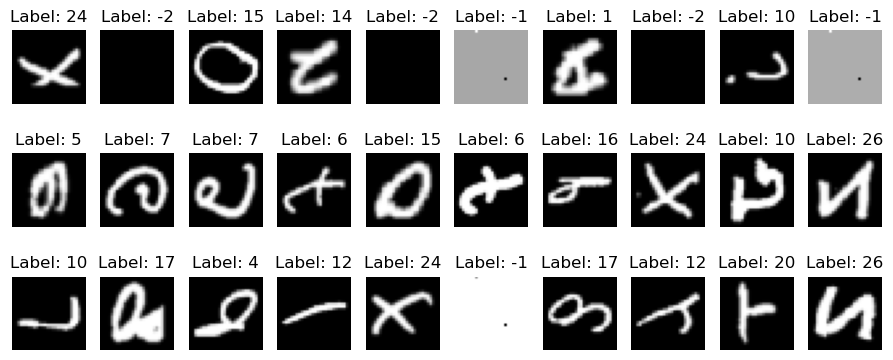

In [5]:
labels = df.iloc[:, 0]
valid_sample_indices = df[labels.between(-2, 26)].head(30).index

plt.figure(figsize=(9, 4))

for i, index in enumerate(valid_sample_indices):
    label = df.iloc[index, 0]
    pixels = df.iloc[index, 1:].values
    test_image = pixels.reshape(28, 28)

    plt.subplot(3, 10, i + 1)
    plt.imshow(test_image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Reflection:** The visual inspection shows that valid labels such as 1 to 26 generally produce recognisable character-like images, although not yet correctly oriented. In contrast, rows labelled `-1` and `-2` appear mostly blank, grey, or distorted instead of showing clear letters. Since `-1` and `-2` are outside the expected label range and do not represent valid alphabet classes, these rows might need to be removed before training the CNN. We should confirm that by visualising those classes in next step.


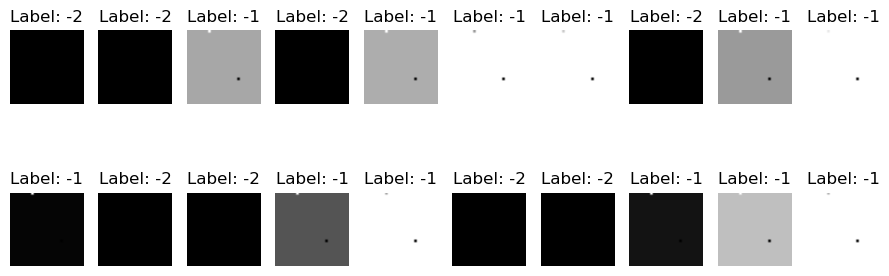

In [22]:
labels = df.iloc[:, 0]
invalid_sample_indices = df[labels.between(-2, -1)].head(20).index

plt.figure(figsize=(9, 4))

for i, index in enumerate(invalid_sample_indices):
    label = df.iloc[index, 0]
    pixels = df.iloc[index, 1:].values
    test_image = pixels.reshape(28, 28)

    plt.subplot(2, 10, i + 1)
    plt.imshow(test_image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Reflection:** When only the `-1` and `-2` labelled rows are displayed, the images do not show meaningful letter shapes. Most samples appear blank, flat-coloured, or contain only small dots/noise. This confirms that these rows are not valid character images for the 26-letter classification task. Therefore, removing `-1` and `-2` rows is justified because keeping them would introduce noisy samples that do not belong to any target class.


### 2.3 Finding the suitable image rotation

After reshaping the pixel values into 28 x 28 images, the letters appeared sideways or incorrectly oriented. Rotation of 90 degree, -90 degree and transpose are tested.

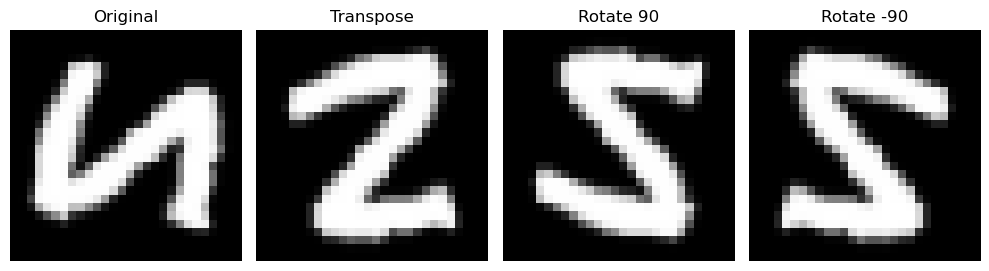

In [25]:
image = pixels.reshape(28, 28)

plt.figure(figsize=(10, 3))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(image.T, cmap="gray")
plt.title("Transpose")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(np.rot90(image, 1), cmap="gray")
plt.title("Rotate 90")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(np.rot90(image, -1), cmap="gray")
plt.title("Rotate -90")
plt.axis("off")

plt.tight_layout()
plt.show()


The transposed images looked more like upright letters, so transpose was chosen as the orientation correction step. This is different from data augmentation because it is a fixed preprocessing correction applied consistently to all images.

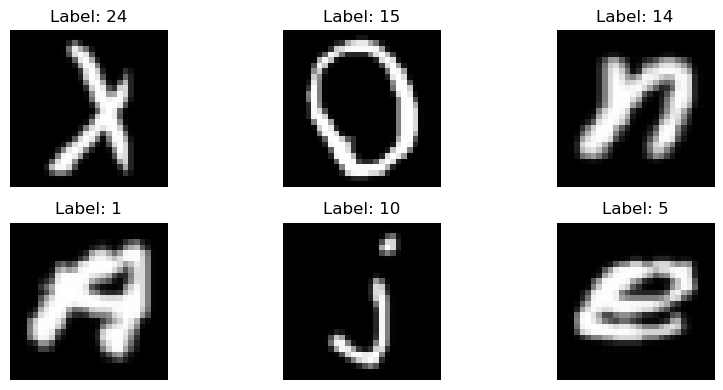

In [33]:
plt.figure(figsize=(9, 4))

for i, index in enumerate(valid_sample_indices):
    label = df.iloc[index, 0]
    pixels = df.iloc[index, 1:].values
    image = pixels.reshape(28, 28).T

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Reflection:** If the transposed images look more upright, the model input should use the transposed orientation. This makes the image representation closer to the actual letter shape.

### 2.4 Label validity check
The labels are already checked in "2.1" against the expected EMNIST letter range of 1 to 26, representing A to Z.
We will now inspect how many rows are classified with invalid labels and will remove those rows in later steps.

In [10]:
invalid_labels = df[(labels < 1) | (labels > 26)]

print("Number of invalid label rows:", len(invalid_labels))
invalid_labels.count()

Number of invalid label rows: 10240


0      10240
1      10240
2      10240
3      10240
4      10240
       ...  
780    10240
781    10240
782    10240
783    10240
784    10240
Length: 785, dtype: int64

**Reflection:** Rows with labels outside 1 to 26 should not be used for the 26-class letter classifier. I will remove them before training.

### 2.5 Duplicate and pixel quality check
Duplicate rows and invalid pixel values are checked before modelling to avoid training on unreliable data.

First, we check for exact duplicate rows in the dataset. A high number of duplicates may cause the model to see repeated samples during training, which can make evaluation less reliable.

In [36]:
duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 9465


Next, we check the pixel value range. Since the images are grayscale, valid pixel values should normally be between 0 and 255.

In [37]:
pixels_df = df.iloc[:, 1:]

print("Minimum pixel value:", pixels_df.min().min())
print("Maximum pixel value:", pixels_df.max().max())

Minimum pixel value: 0
Maximum pixel value: 345


Finally, I identify rows with pixel values below 0 or above 255. These rows are considered corrupted because they do not follow the expected grayscale image range.

In [38]:
corrupted_rows = df[
    (pixels_df < 0).any(axis=1) | 
    (pixels_df > 255).any(axis=1)
]

print("Number of corrupted rows:", len(corrupted_rows))
corrupted_rows.head()

Number of corrupted rows: 1


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
48583,-1,89,89,89,89,89,89,89,89,200,...,89,89,89,89,89,89,89,89,89,89


**Reflection:** The duplicate and pixel quality checks show that the raw dataset contains 9,465 duplicated rows and 1 corrupted row with a pixel value outside the valid grayscale range of 0 to 255. The maximum pixel value is 345, which is not valid for an image pixel. This corrupted row also has an invalid label of `-1`, so it will be removed when invalid labels and invalid pixel rows are cleaned. 

**Key takeaways from data inspection:**

- The dataset contains valid labels from 1 to 26, which represent the 26 alphabet classes.
- Invalid labels `-1` and `-2` were found and inspected separately.
- Images with labels `-1` and `-2` appeared blank, distorted, or noisy, so they are not suitable for training.
- The raw reshaped images were not correctly oriented, so different orientation options were tested.
- Transpose was selected because it produced the most readable letter images.
- Duplicate rows and pixel quality were checked to identify possible data quality issues.
- One corrupted row had a pixel value outside the valid grayscale range of 0 to 255.
- Based on these checks, invalid labels and corrupted pixel rows should be removed before model training.


## 3. Exploratory data analysis

### 3.1 Label distribution

The class distribution is checked using only valid labels from 1 to 26. This helps determine whether the dataset is balanced across all alphabet classes before training the CNN.


In [39]:
valid_labels = labels[labels.between(1, 26)]
class_counts = valid_labels.value_counts().sort_index()

print(class_counts)

0
1     3396
2     3396
3     3419
4     3398
5     3437
6     3394
7     3385
8     3424
9     3428
10    3402
11    3438
12    3415
13    3402
14    3365
15    3408
16    3430
17    3435
18    3419
19    3392
20    3436
21    3419
22    3422
23    3423
24    3437
25    3453
26    3427
Name: count, dtype: int64


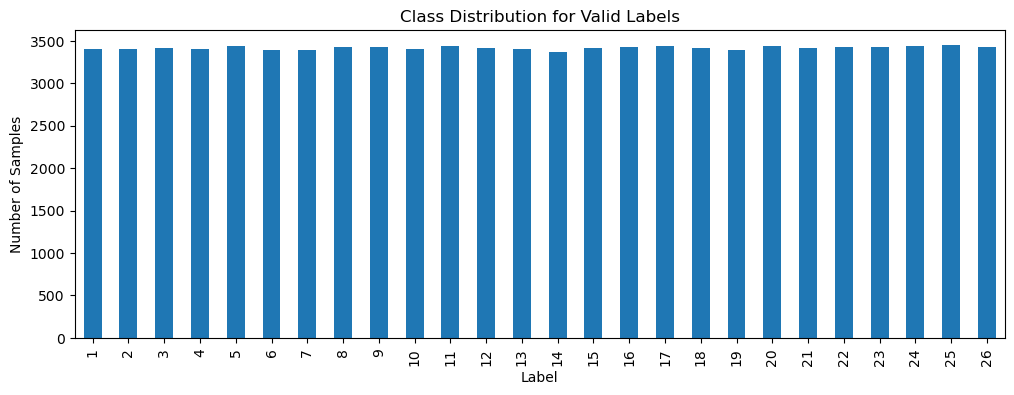

In [40]:
plt.figure(figsize=(12, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution for Valid Labels")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.show()

**Reflection:** The class distribution for valid labels is fairly balanced, with each label having a similar number of samples. This means the CNN should receive roughly equal exposure to all 26 letter classes during training. Since there is no major class imbalance, special balancing techniques are not necessary at this stage.


### 3.2 Class sample inspection

One representative sample from each valid class is displayed after cleaning along with orientation correction. This helps visually confirm that every label from 1 to 26 contains character-like images and that the transpose step makes the letters more readable.


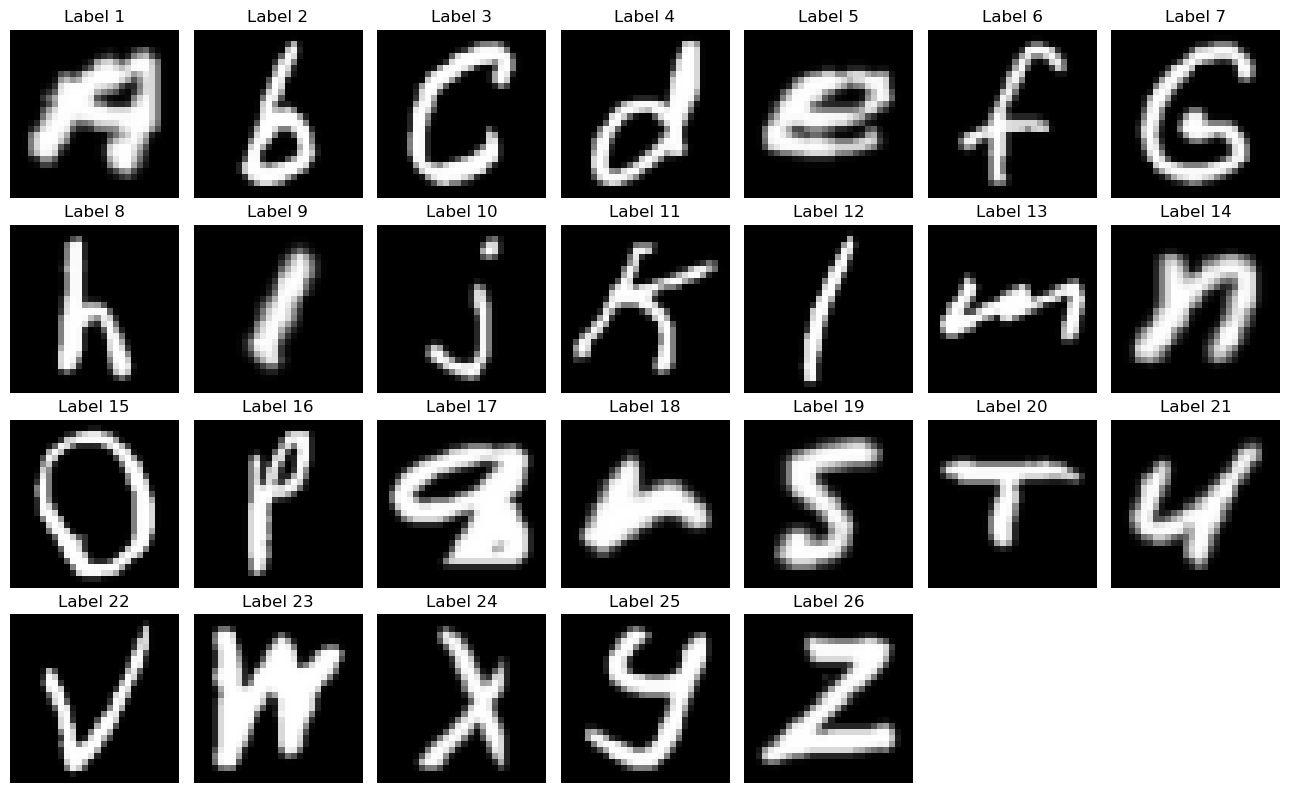

In [32]:
plt.figure(figsize=(13, 8))

for label in range(1, 27):
    sample_row = clean_df[clean_df.iloc[:, 0] == label].iloc[0]
    image = sample_row.iloc[1:].values.reshape(28, 28).T

    plt.subplot(4, 7, label)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


**Reflection:** The representative samples from labels 1 to 26 show recognisable letter-like images. This confirms that the valid classes contain usable character data for CNN training. Some letters still vary in handwriting style, thickness, and shape, which is expected in handwritten character datasets. These variations make the classification task more realistic and justify using a CNN to learn visual patterns from the images.


### 3.3 Average image pattern inspection

The average image for each class is generated by taking the mean pixel value across all samples with the same label. This helps reveal the general shape pattern of each letter class and shows whether the images within each label are broadly consistent.


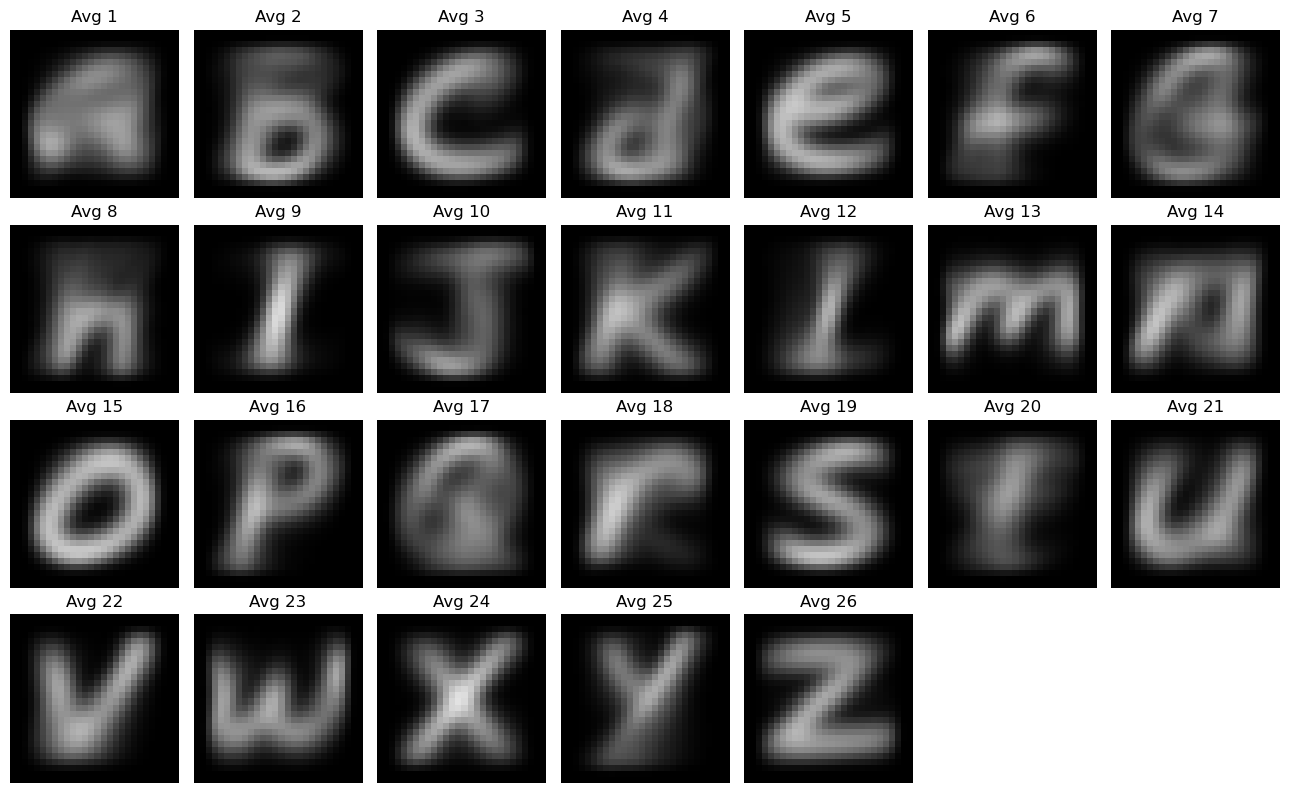

In [34]:
plt.figure(figsize=(13, 8))

for label in range(1, 27):
    class_pixels = df[labels == label].iloc[:, 1:].values
    average_image = class_pixels.mean(axis=0).reshape(28, 28).T

    plt.subplot(4, 7, label)
    plt.imshow(average_image, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Avg {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


**Reflection:** The average images show that each valid label has a clear overall letter pattern, although the images appear blurred because they are averaged across many handwriting styles. This suggests that the labels are generally consistent and that each class contains meaningful visual structure. Some classes have shapes that look visually similar, so the CNN may later confuse certain letters, but the averaged patterns confirm that the cleaned dataset is suitable for model training.


**Key takeaways from exploratory data analysis:**

- The valid class distribution is fairly balanced across all 26 labels.
- Since the classes have similar sample counts, class weighting is not necessary at this stage.
- Representative samples from each class show recognisable handwritten letter-like images.
- The samples show natural handwriting variation in shape, stroke thickness, and style.
- Average images reveal a clear general pattern for each label, suggesting that the labels are mostly consistent.
- Some letter shapes appear visually similar, so the CNN may confuse certain classes later.
- Overall, the cleaned dataset is suitable for CNN-based image classification.


## 4. CNN input preparation
The cleaned data is reshaped into 28 x 28 x 1 grayscale images and scaled from 0-255 to 0-1 for stable training.

The dataset is cleaned by keeping only valid labels from 1 to 26 and removing rows with pixel values outside the valid grayscale range of 0 to 255. This ensures that only valid character images are used for model training.

In [15]:
clean_df = df[labels.between(1, 26)].copy()
clean_pixels_df = clean_df.iloc[:, 1:]

clean_df = clean_df[
    (clean_pixels_df >= 0).all(axis=1) &
    (clean_pixels_df <= 255).all(axis=1)
].copy()

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(clean_df))

Rows before cleaning: 99040
Rows after cleaning: 88800


### 4.2 Separate feature and labels

The cleaned dataset is separated into input features and target labels. The feature values contain the 784 pixel values for each image, while the labels represent the correct letter class. The labels are shifted from 1-26 to 0-25 because neural network classification labels are commonly represented using zero-based class indices.


In [16]:
X_pixels = clean_df.iloc[:, 1:].values
y_labels = clean_df.iloc[:, 0].values
y_labels = y_labels - 1

print("X_pixels shape:", X_pixels.shape)
print("y_labels shape:", y_labels.shape)
print("Minimum label after conversion:", y_labels.min())
print("Maximum label after conversion:", y_labels.max())

X_pixels shape: (88800, 784)
y_labels shape: (88800,)
Minimum label after conversion: 0
Maximum label after conversion: 25


### 4.3 Image reshape and transpose

The 784 pixel values in each row are reshaped into a 28 x 28 image. This converts the flat tabular format into the two-dimensional image format needed for visual inspection and CNN processing.

In [17]:
# Reshape flat pixels into 28 x 28 images
X_images = X_pixels.reshape(-1, 28, 28)

print("X_images shape before transpose:", X_images.shape)


X_images shape before transpose: (88800, 28, 28)


After reshaping, the EMNIST images are transposed to correct their orientation. This keeps the same pixel information but swaps the image axes so the letters appear more readable.


In [18]:
# Correct EMNIST image orientation
X_images = np.transpose(X_images, (0, 2, 1))

print("X_images shape after transpose:", X_images.shape)

X_images shape after transpose: (88800, 28, 28)


The pixel values are normalised from the original 0-255 range to 0-1. This helps the CNN train more stably because the input values are kept within a smaller numerical range.


In [19]:
# Normalise pixel values from 0-255 to 0-1
X_images = X_images / 255.0

print("Minimum pixel after scaling:", X_images.min())
print("Maximum pixel after scaling:", X_images.max())

Minimum pixel after scaling: 0.0
Maximum pixel after scaling: 1.0


A channel dimension is added so the image data matches the CNN input format. Since these are grayscale images, each image has one channel, giving the final input shape of 28 x 28 x 1.


In [20]:
# Add channel dimension for CNN input
X_images = X_images.reshape(-1, 28, 28, 1)

print("Final X shape:", X_images.shape)

Final X shape: (88800, 28, 28, 1)


**Reflection:** After cleaning, transposing, reshaping, and scaling, each sample is ready for CNN training in the shape `(28, 28, 1)`.

### 4.4 Train Test split

The cleaned dataset is split into training, validation, and test sets using a 70:10:20 ratio. The training set is the largest portion because the CNN needs enough data to learn useful image features. The validation set is kept smaller and is used during training to monitor performance on unseen data and guide model tuning. The test set is kept separate and used only for final evaluation, giving a more unbiased estimate of the model's performance.

A fixed seed value of 88 is used to make the split reproducible, so the same rows are assigned to each set whenever the notebook is rerun. Stratified splitting is also used to preserve the class distribution across the training, validation, and test sets. This is important because the task has 26 letter classes, and each split should contain a similar proportion of each class for fair training and evaluation.


In [21]:
SEED = 88

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


X_train, X_temp, y_train, y_temp = train_test_split(
    X_images,
    y_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=y_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    random_state=SEED,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)


X_train: (62160, 28, 28, 1)
X_val: (8880, 28, 28, 1)
X_test: (17760, 28, 28, 1)
y_train: (62160,)
y_val: (8880,)
y_test: (17760,)


## 5. Baseline Model 

The baseline model is a simple CNN used as the first reference model. It uses two convolution and pooling blocks to learn image features from the 28 x 28 grayscale letter images. Dropout is included to reduce overfitting, and the final dense layer uses 26 output nodes because there are 26 letter classes.

This model is intentionally kept simple so that later improvements can be compared against a clear starting point.


In [17]:
num_classes = 26

In [31]:
baseline_model = Sequential()

baseline_model.add(Conv2D(30, (5, 5), input_shape=(28, 28, 1), activation="relu"))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

baseline_model.add(Conv2D(15, (3, 3), activation="relu"))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

baseline_model.add(Dropout(0.2))
baseline_model.add(Flatten())

baseline_model.add(Dense(501, activation="relu"))
baseline_model.add(Dense(num_classes, activation="softmax"))

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 24, 24, 30)        780       
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 12, 12, 30)       0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 10, 10, 15)        4065      
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 5, 5, 15)         0         
 g2D)                                                            
                                                                 
 dropout_10 (Dropout)        (None, 5, 5, 15)          0         
                                                                 
 flatten_5 (Flatten)         (None, 375)              

The model summary shows that the baseline CNN has 206,273 trainable parameters. The convolution layers reduce the image from 28 x 28 to smaller feature maps while learning visual patterns such as strokes, curves, and edges. The pooling layers reduce the feature map size, and the flatten layer converts the extracted features into a 1D vector for classification. Most of the parameters are in the dense layer, which means the final classification stage contributes most of the model complexity.


In [32]:
baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=200,
    verbose=1
)

# Final evaluation of the baseline model
scores = baseline_model.evaluate(X_val, y_val, verbose=0)

print("Baseline Loss: %.4f" % scores[0])
print("Baseline Accuracy: %.2f%%" % (scores[1] * 100))
print("Baseline Error: %.2f%%" % (100 - scores[1] * 100))



Epoch 1/5
311/311 [==============================] - 2s 6ms/step - loss: 0.9326 - accuracy: 0.7222 - val_loss: 0.4008 - val_accuracy: 0.8784
Epoch 2/5
311/311 [==============================] - 2s 6ms/step - loss: 0.3844 - accuracy: 0.8763 - val_loss: 0.2843 - val_accuracy: 0.9087
Epoch 3/5
311/311 [==============================] - 2s 6ms/step - loss: 0.3017 - accuracy: 0.9008 - val_loss: 0.2510 - val_accuracy: 0.9190
Epoch 4/5
311/311 [==============================] - 2s 6ms/step - loss: 0.2586 - accuracy: 0.9145 - val_loss: 0.2216 - val_accuracy: 0.9251
Epoch 5/5
311/311 [==============================] - 2s 6ms/step - loss: 0.2313 - accuracy: 0.9206 - val_loss: 0.2119 - val_accuracy: 0.9298
Baseline Loss: 0.2119
Baseline Accuracy: 92.97%
Baseline Error: 7.03%


**Reflection:** The baseline model achieved a validation accuracy of nearly 92% and a validation error of 7-8%. Training accuracy improved steadily from 90% to 93%, showing that the model was learning from the training data. Validation accuracy also improved from 91% to 93% before ending at 92%, which suggests that the model generalises reasonably well but may have started to fluctuate after the third epoch. Since the training and validation accuracies are close, there is no strong sign of overfitting at this stage. This baseline result provides a useful reference point for later model improvement.


### 5.1 Baseline Accuracy graph
The training and validation accuracy curves are plotted to inspect how the baseline model learns over the epochs. Comparing these two curves helps identify whether the model is improving steadily, underfitting, or starting to overfit.


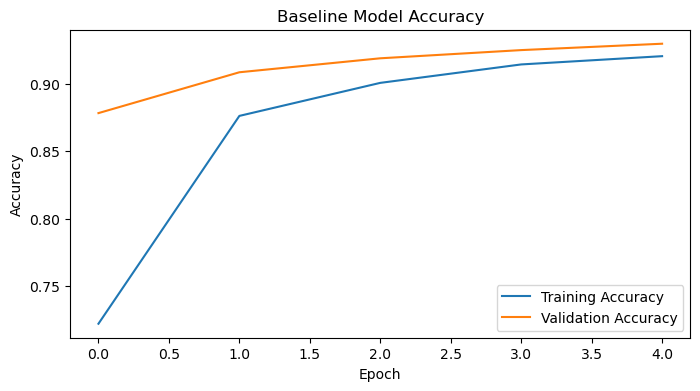

In [39]:
plt.figure(figsize=(8, 4))

plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


**Reflection:** The accuracy plot shows that training accuracy increases steadily across the 5 epochs, meaning the baseline model is learning from the training data. Validation accuracy is already high and stays close to the training accuracy, which suggests that the model generalises reasonably well. The validation accuracy peaks around epoch 2 and then flatten as we train more, so training for more epochs may not always improve validation performance unless additional regularisation or tuning is applied.


### 5.2 Baseline Loss graph

The training and validation loss curves are plotted to understand how the model's error changes during training. Loss is useful because it shows not only whether predictions are correct, but also how confident or uncertain the model is.


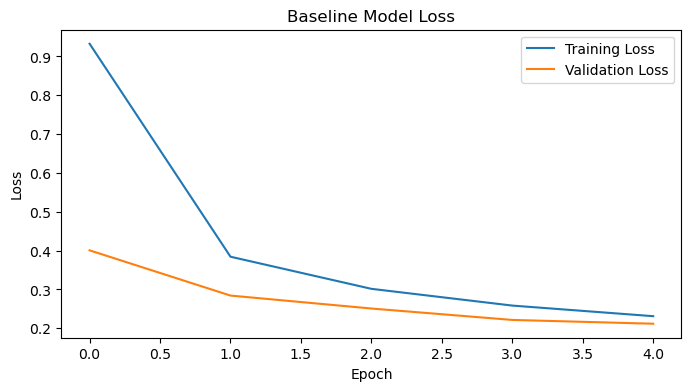

In [40]:
plt.figure(figsize=(8, 4))

plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")

plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


**Reflection:** The training loss decreases steadily across all 5 epochs, showing that the model is continuing to learn from the training data. The validation loss decreases steadily until around epoch 2, then starts to flatten slightly while training loss continues to fall. For later improvement, early stopping or stronger regularisation can be considered to keep the model from training beyond the point where validation performance stops improving.


### 5.3 Confusion matrix

A normalized confusion matrix is plotted using the validation set to analyse class-level performance. Each row represents the true letter class, and each column represents the predicted letter class. The values are normalized by row, so they show the proportion of samples from each true class that were predicted as each class. This makes it easier to compare mistakes across classes even if class counts are not exactly the same.


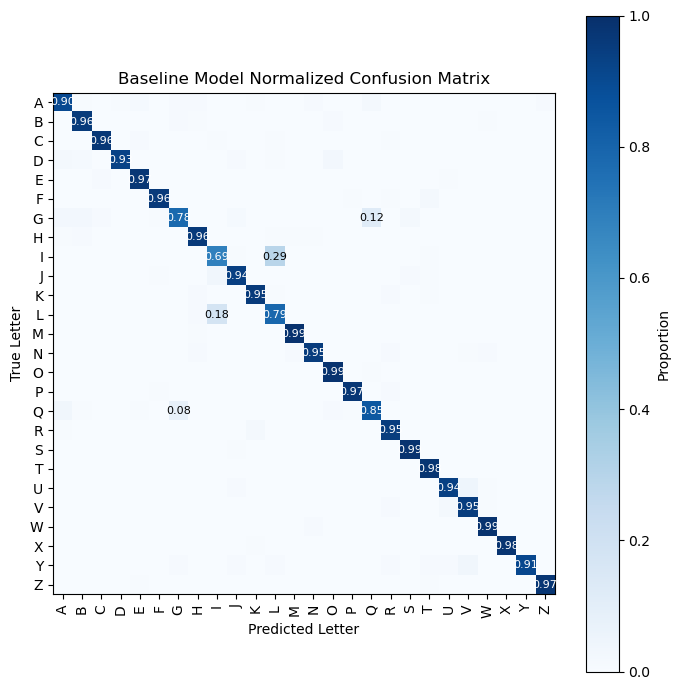

In [41]:
class_names = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

# Predict validation classes
y_val_pred_probs = baseline_model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Normalize by true class row
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 7))
plt.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)

plt.title("Baseline Model Normalized Confusion Matrix")
plt.xlabel("Predicted Letter")
plt.ylabel("True Letter")

plt.xticks(range(26), class_names, rotation=90)
plt.yticks(range(26), class_names)

plt.colorbar(label="Proportion")

# Add text annotations
for i in range(26):
    for j in range(26):
        value = cm_normalized[i, j]
        if value >= 0.05:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if value > 0.5 else "black",
                fontsize=8
            )

plt.tight_layout()
plt.show()


**Reflection:** The normalized confusion matrix shows strong diagonal values for most letters, which means the baseline model correctly classifies many classes with high confidence. Several letters such as B, C, F, M, S, W, X, and Z have very high correct prediction proportions. However, some classes show weaker performance, especially G, I, L, Q, and U. The main confusions include I being predicted as L, L being predicted as I, G being confused with Q, and U being confused with V. These mistakes are reasonable because some handwritten letters have similar shapes. This suggests that later model improvements should focus on helping the CNN better distinguish visually similar letter classes.


### 5.4 Common confused classes

The diagonal values of the confusion matrix represent correct predictions, so they are removed here to focus only on misclassifications. The remaining values are sorted to identify the most common confused letter pairs in the baseline model.


In [42]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

confusions = []

for true_idx in range(26):
    for pred_idx in range(26):
        count = cm_no_diag[true_idx, pred_idx]
        if count > 0:
            confusions.append((class_names[true_idx], class_names[pred_idx], count))

confusions = sorted(confusions, key=lambda x: x[2], reverse=True)

print("Top 10 Confused Letter Pairs")
for true_letter, pred_letter, count in confusions[:10]:
    print(f"True {true_letter} predicted as {pred_letter}: {count} times")


Top 10 Confused Letter Pairs
True I predicted as L: 100 times
True L predicted as I: 61 times
True G predicted as Q: 40 times
True Q predicted as G: 27 times
True U predicted as V: 15 times
True Q predicted as A: 12 times
True J predicted as I: 11 times
True Y predicted as V: 11 times
True D predicted as O: 9 times
True G predicted as A: 8 times


**Reflection:** The top confused pairs show that most baseline errors occur between letters with similar handwritten shapes. The strongest confusion is between I and L, which is expected because both can appear as simple vertical strokes depending on handwriting style. G and Q are also confused with each other because they share similar circular shapes, while U and V can look alike when handwritten with sharp or narrow curves. These results suggest that the baseline model is learning useful features, but it still struggles with fine-grained differences between visually similar letters. This gives a clear direction for model improvement and tunings.


#### 5.4.1 Sample confused classes

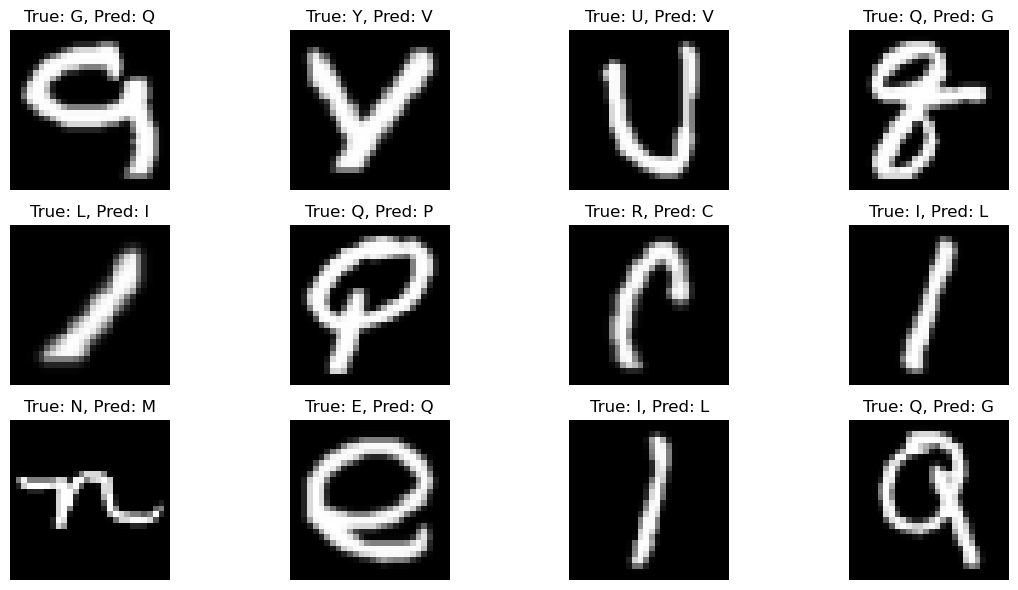

In [43]:
wrong_indices = np.where(y_val != y_val_pred)[0]

plt.figure(figsize=(12, 6))

for i, index in enumerate(wrong_indices[:12]):
    image = X_val[index].reshape(28, 28)
    true_label = class_names[y_val[index]]
    pred_label = class_names[y_val_pred[index]]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


**Reflection:** The misclassified samples show that many errors occur between letters with very similar handwritten shapes. For example, `I` and `L` can both appear as a single vertical stroke, while `G` and `Q` both have circular shapes with small tail-like strokes. Some samples are also written in unusual styles, such as `Y` looking similar to `V` or `N` looking close to `M`, which makes classification harder even for a CNN. These examples suggest that the model is not failing randomly; most mistakes happen when the visual difference between classes is small or when the handwriting style is ambiguous.


### 5.5 What we learned from the baseline model

The baseline CNN achieved a validation accuracy of 92.97%, showing that even a simple convolutional model can learn useful features from the cleaned EMNIST letter images. The training and validation accuracy both improved across the 5 epochs, so the model was learning meaningful patterns rather than guessing randomly.

However, the validation curves and confusion analysis show clear areas for improvement. The validation loss improved at first but did not continue improving as strongly as training loss, suggesting that the model may begin to overfit if trained for longer. The confusion matrix also showed that the baseline struggled most with visually similar handwritten letters, especially `I` and `L`, `G` and `Q`, and `U` and `V`.

These findings suggest that the next improvements should focus on learning more detailed visual features while controlling overfitting. Therefore, later models will test stronger CNN feature extraction, different activation behaviour, batch normalization, dropout tuning, and data augmentation.


#### **Note on result stability:** 
Although a fixed random seed is used, CNN training results may still vary slightly between runs because neural network weights are randomly initialised and TensorFlow/GPU operations may not be fully deterministic. Therefore, small differences in validation accuracy, validation loss, or confused class counts are expected when the notebook is rerun. For this reason, the baseline result is treated as an approximate reference point for comparison rather than an exact fixed value.


## 6. Model Improvement

### 6.1 Improved Model 1: Stronger CNN Feature Extraction

Improved Model 1 was designed based on the findings from the baseline model and exploratory analysis. The EDA showed that the dataset contains handwritten letters with different stroke thickness, shapes, and writing styles. The baseline confusion analysis also showed that the model struggled with visually similar letters such as `I/L`, `G/Q`, and `U/V`.

To improve feature extraction, the convolution filters were increased from `30` and `15` in the baseline model to `32` and `64`. This gives the CNN more capacity to learn detailed stroke and curve patterns. The kernel size was changed to `3 x 3`, which is commonly used for learning smaller local image features.

Dropout was also increased from `0.20` to `0.25`, and an additional dropout layer of `0.30` was added after the dense layer. This was done because the baseline loss curve suggested possible overfitting when training continued. The dense layer was kept close to the baseline size, changing from `501` to `512`, so the model still has enough classification capacity while keeping the architecture controlled.


In [34]:
improved_model_1 = Sequential()

improved_model_1.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)))
improved_model_1.add(MaxPooling2D(pool_size=(2, 2)))

improved_model_1.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
improved_model_1.add(MaxPooling2D(pool_size=(2, 2)))

improved_model_1.add(Dropout(0.25))
improved_model_1.add(Flatten())

improved_model_1.add(Dense(512, activation="relu"))
improved_model_1.add(Dropout(0.30))
improved_model_1.add(Dense(num_classes, activation="softmax"))

improved_model_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model_1.summary()


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 14, 14, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 7, 7, 64)         0         
 g2D)                                                            
                                                                 
 dropout_11 (Dropout)        (None, 7, 7, 64)          0         
                                                                 
 flatten_6 (Flatten)         (None, 3136)             

**Training setup for Improved Model 1**

Improved Model 1 is trained using the same training and validation split as the baseline model so that the results can be compared fairly. The validation set is used during training to monitor how well the model generalises to unseen data.

The batch size is kept at `200`, the same as the baseline model, so that the main change being tested is the model architecture and dropout adjustment rather than the training batch size. The number of epochs is increased to `20` to give the improved architecture more opportunity to learn. The training and validation loss curves will be checked afterwards to see whether the extra epochs improve performance or lead to overfitting.


In [35]:
improved_history_1 = improved_model_1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=200,
    verbose=1
)


Epoch 1/20
311/311 [==============================] - 3s 9ms/step - loss: 0.7489 - accuracy: 0.7711 - val_loss: 0.3256 - val_accuracy: 0.8905
Epoch 2/20
311/311 [==============================] - 2s 7ms/step - loss: 0.3259 - accuracy: 0.8925 - val_loss: 0.2492 - val_accuracy: 0.9155
Epoch 3/20
311/311 [==============================] - 2s 7ms/step - loss: 0.2619 - accuracy: 0.9121 - val_loss: 0.2208 - val_accuracy: 0.9261
Epoch 4/20
311/311 [==============================] - 2s 7ms/step - loss: 0.2250 - accuracy: 0.9233 - val_loss: 0.2083 - val_accuracy: 0.9287
Epoch 5/20
311/311 [==============================] - 2s 7ms/step - loss: 0.2014 - accuracy: 0.9301 - val_loss: 0.2020 - val_accuracy: 0.9312
Epoch 6/20
311/311 [==============================] - 2s 7ms/step - loss: 0.1835 - accuracy: 0.9345 - val_loss: 0.1920 - val_accuracy: 0.9355
Epoch 7/20
311/311 [==============================] - 2s 7ms/step - loss: 0.1679 - accuracy: 0.9394 - val_loss: 0.1894 - val_accuracy: 0.9360
Epoch 

In [36]:
improved_1_val_loss, improved_1_val_accuracy = improved_model_1.evaluate(X_val, y_val, verbose=0)

print("Improved Model 1 Validation Loss: %.4f" % improved_1_val_loss)
print("Improved Model 1 Validation Accuracy: %.2f%%" % (improved_1_val_accuracy * 100))
print("Improved Model 1 Validation Error: %.2f%%" % (100 - improved_1_val_accuracy * 100))


Improved Model 1 Validation Loss: 0.2064
Improved Model 1 Validation Accuracy: 93.98%
Improved Model 1 Validation Error: 6.02%


**Reflection:** Improved Model 1 achieved a validation accuracy of 93.98% and a validation loss of 0.2064. Compared with the baseline model, which achieved 92.97% validation accuracy and 0.2119 validation loss, this is a clear improvement. The validation error decreased from 7.03% to 6.02%, showing that increasing the convolution filters, using 3 x 3 kernels, and adding slightly stronger dropout helped the model learn better visual features. However, the improvement is still moderate, so further experiments are needed to see whether activation functions, normalisation, or additional regularisation can improve performance further.


#### 6.1.1 Model 1 Accuracy Graph

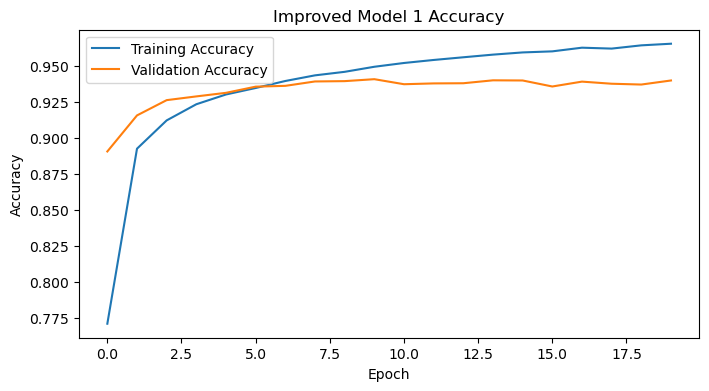

In [37]:
plt.figure(figsize=(8, 4))

plt.plot(improved_history_1.history["accuracy"], label="Training Accuracy")
plt.plot(improved_history_1.history["val_accuracy"], label="Validation Accuracy")

plt.title("Improved Model 1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


The improved model performs well, with training accuracy rising above 0.96 and validation accuracy staying around 0.94. This shows the model learns well and generalises quite well.

However, after around epoch 7 to 10, the training accuracy continues to increase while the validation accuracy becomes mostly flat and slightly fluctuates. This suggests mild overfitting, because the model keeps improving on the training data but does not improve much on the validation data.

#### 6.1.2 Model 1 Loss Graph

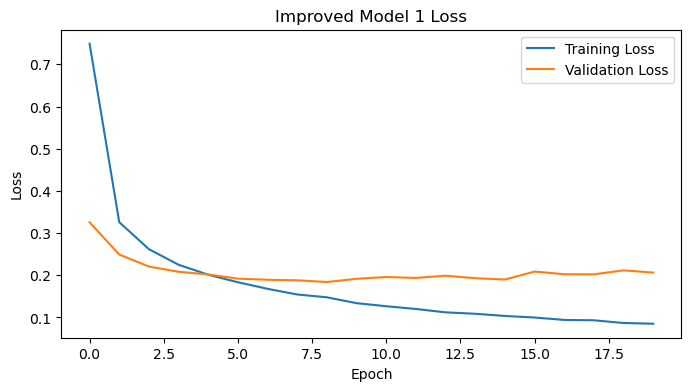

In [38]:
plt.figure(figsize=(8, 4))

plt.plot(improved_history_1.history["loss"], label="Training Loss")
plt.plot(improved_history_1.history["val_loss"], label="Validation Loss")

plt.title("Improved Model 1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


The loss graph shows the model improves quickly at the start, with both training and validation loss dropping. After around epoch 5, training loss keeps decreasing, but validation loss stays almost flat and slightly increases.

This suggests slight overfitting. The model is learning the training data more, but validation performance is no longer improving much.

#### 6.1.3 Model 1 Evaluation Compared with Baseline

Compared to the baseline model, Improved Model 1 performs better because it reaches higher accuracy and lower loss. The validation accuracy stays around 0.94, showing that the improved model generalises well to unseen data.

The loss also decreases much more smoothly, especially in the early epochs. However, after a few epochs, the validation loss becomes mostly flat while training loss keeps decreasing, which suggests slight overfitting.

### 6.2 Improved Model 2: LeakyReLU and Batch Size Adjustment

Improved Model 2 keeps the main structure of Improved Model 1 but changes the activation function from ReLU to LeakyReLU. This was tested because LeakyReLU allows a small gradient for negative activations, which may help the model continue learning useful features instead of completely zeroing negative values.

The batch size is also reduced from `200` to `128`. A smaller batch size gives more frequent weight updates, which may improve optimisation, although it can slightly increase training time. This experiment checks whether activation behaviour and training settings can improve the model beyond the architecture changes in Improved Model 1.

In [44]:
improved_model_2 = Sequential()

improved_model_2.add(Conv2D(32, (3, 3), padding="same", input_shape=(28, 28, 1)))
improved_model_2.add(LeakyReLU(alpha=0.1))
improved_model_2.add(MaxPooling2D(pool_size=(2, 2)))

improved_model_2.add(Conv2D(64, (3, 3), padding="same"))
improved_model_2.add(LeakyReLU(alpha=0.1))
improved_model_2.add(MaxPooling2D(pool_size=(2, 2)))

improved_model_2.add(Dropout(0.25))
improved_model_2.add(Flatten())

improved_model_2.add(Dense(512))
improved_model_2.add(LeakyReLU(alpha=0.1))
improved_model_2.add(Dropout(0.30))

improved_model_2.add(Dense(num_classes, activation="softmax"))

improved_model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model_2.summary()


Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_14 (Conv2D)          (None, 28, 28, 32)        320       
                                                                 
 leaky_re_lu_11 (LeakyReLU)  (None, 28, 28, 32)        0         
                                                                 
 max_pooling2d_14 (MaxPoolin  (None, 14, 14, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_15 (Conv2D)          (None, 14, 14, 64)        18496     
                                                                 
 leaky_re_lu_12 (LeakyReLU)  (None, 14, 14, 64)        0         
                                                                 
 max_pooling2d_15 (MaxPoolin  (None, 7, 7, 64)         0         
 g2D)                                                 

**Training setup for Improved Model 2**

Improved Model 2 uses the same training and validation sets so that the comparison with the previous models remains fair. The number of epochs is kept at `20`, while the batch size is changed to `128` to test whether more frequent updates improve validation performance.

In [45]:
improved_history_2 = improved_model_2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)


Epoch 1/20
486/486 [==============================] - 4s 7ms/step - loss: 0.6429 - accuracy: 0.8018 - val_loss: 0.2890 - val_accuracy: 0.9050
Epoch 2/20
486/486 [==============================] - 3s 6ms/step - loss: 0.2990 - accuracy: 0.9011 - val_loss: 0.2302 - val_accuracy: 0.9276
Epoch 3/20
486/486 [==============================] - 3s 6ms/step - loss: 0.2420 - accuracy: 0.9180 - val_loss: 0.2235 - val_accuracy: 0.9285
Epoch 4/20
486/486 [==============================] - 3s 6ms/step - loss: 0.2130 - accuracy: 0.9260 - val_loss: 0.2065 - val_accuracy: 0.9321
Epoch 5/20
486/486 [==============================] - 3s 6ms/step - loss: 0.1869 - accuracy: 0.9347 - val_loss: 0.1996 - val_accuracy: 0.9343
Epoch 6/20
486/486 [==============================] - 3s 6ms/step - loss: 0.1717 - accuracy: 0.9382 - val_loss: 0.2040 - val_accuracy: 0.9340
Epoch 7/20
486/486 [==============================] - 3s 6ms/step - loss: 0.1597 - accuracy: 0.9411 - val_loss: 0.1917 - val_accuracy: 0.9378
Epoch 

In [46]:
improved_2_val_loss, improved_2_val_accuracy = improved_model_2.evaluate(X_val, y_val, verbose=0)

print("Improved Model 2 Validation Loss: %.4f" % improved_2_val_loss)
print("Improved Model 2 Validation Accuracy: %.2f%%" % (improved_2_val_accuracy * 100))
print("Improved Model 2 Validation Error: %.2f%%" % (100 - improved_2_val_accuracy * 100))


Improved Model 2 Validation Loss: 0.2156
Improved Model 2 Validation Accuracy: 93.89%
Improved Model 2 Validation Error: 6.11%


**Reflection:** Improved Model 2 achieved a validation accuracy of 93.89% and a validation loss of 0.2156. This is still better than the baseline accuracy of 92.97%, but it is slightly weaker than Improved Model 1. This suggests that replacing ReLU with LeakyReLU and reducing the batch size did not give a clear improvement for this dataset. The result is still useful because it shows that not every reasonable training change improves validation performance.

#### 6.2.1 Model 2 Accuracy Graph

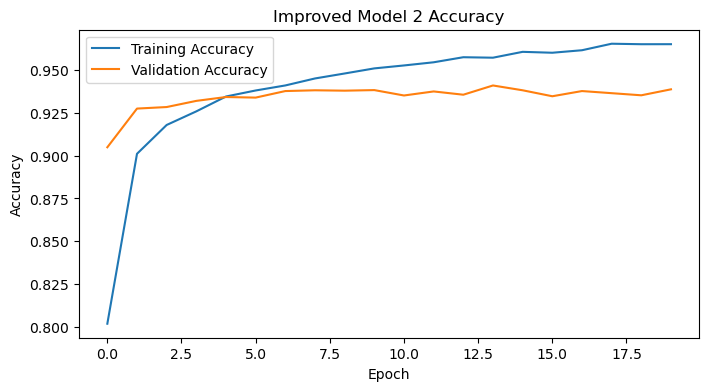

In [47]:
plt.figure(figsize=(8, 4))

plt.plot(improved_history_2.history["accuracy"], label="Training Accuracy")
plt.plot(improved_history_2.history["val_accuracy"], label="Validation Accuracy")

plt.title("Improved Model 2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Reflection:** The accuracy graph for Improved Model 2 shows that training accuracy increases steadily across the epochs, while validation accuracy improves early and then stays mostly flat around 93-94%. The gap between training and validation accuracy becomes larger over time, which suggests mild overfitting. This means the LeakyReLU and smaller batch size helped the model learn the training data well.


#### 6.2.2 Model 2 Loss Graph

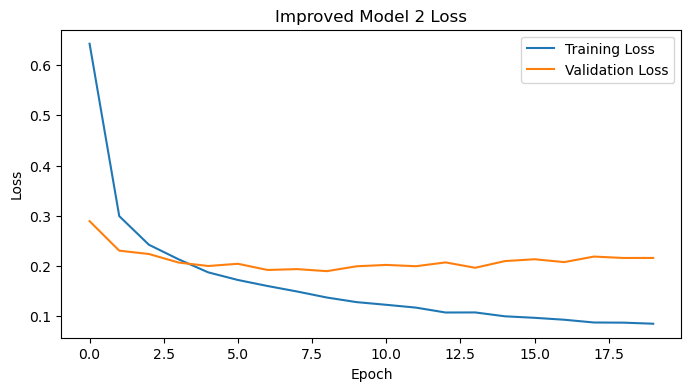

In [48]:
plt.figure(figsize=(8, 4))

plt.plot(improved_history_2.history["loss"], label="Training Loss")
plt.plot(improved_history_2.history["val_loss"], label="Validation Loss")

plt.title("Improved Model 2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


**Reflection:** The loss graph for Improved Model 2 shows that training loss decreases steadily throughout training, meaning the model continues to fit the training data better over time. However, validation loss drops only during the early epochs and then becomes mostly flat or slightly increases. This widening gap between training loss and validation loss suggests overfitting. Therefore, the LeakyReLU and smaller batch size helped the model learn the training set, but did not clearly improve generalisation.

#### 6.2.3 Model 2 Evaluation Compared with Previous Models

Compared with the baseline, Improved Model 2 still performs better because its validation accuracy remains higher than the baseline result. However, it does not improve over Improved Model 1. The validation loss is also higher than Model 1, which suggests that changing to LeakyReLU and reducing the batch size did not provide a clear benefit in this experiment.

This result is useful because it shows that a reasonable change in activation function and training setting does not always improve generalisation. The model learns the training data well, but the validation curves suggest mild overfitting.

### 6.3 Improved Model 3: Batch Normalization and Stronger Regularisation

Improved Model 3 tests Batch Normalization after the convolution layers. This was chosen because the previous models showed validation loss fluctuation while training loss continued to decrease, which suggests that the model may be fitting the training data more strongly than the validation data. Batch Normalization helps stabilise learning by normalising intermediate activations, which can make training smoother and reduce sensitivity to weight updates.

The dense layer is reduced from `512` to `384` because the dense layer contains most of the trainable parameters after flattening. Reducing this layer lowers model complexity and may help reduce overfitting. Dropout is also increased slightly to make the model rely less on specific neurons during training.

These adjustments are based on the baseline and previous improvement results: the model needs enough capacity to distinguish visually similar letters, but it also needs stronger regularisation because validation performance does not keep improving as training performance increases.
The dense layer is reduced from `512` to `384`, and dropout is increased slightly. These changes aim to reduce model complexity and overfitting while keeping enough capacity to classify the 26 letter classes.

In [23]:
improved_model_3 = Sequential()

improved_model_3.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)))
improved_model_3.add(BatchNormalization())
improved_model_3.add(MaxPooling2D(pool_size=(2, 2)))

improved_model_3.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
improved_model_3.add(BatchNormalization())
improved_model_3.add(MaxPooling2D(pool_size=(2, 2)))

improved_model_3.add(Dropout(0.30))
improved_model_3.add(Flatten())

improved_model_3.add(Dense(384, activation="relu"))
improved_model_3.add(Dropout(0.35))
improved_model_3.add(Dense(num_classes, activation="softmax"))

improved_model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model_3.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 batch_normalization_2 (Batc  (None, 28, 28, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_3 (Batc  (None, 14, 14, 64)       256       
 hNormalization)                                                 
                                                      

In [24]:
improved_history_3 = improved_model_3.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=200,
    verbose=1
)


Epoch 1/20
486/486 [==============================] - 4s 8ms/step - loss: 0.7207 - accuracy: 0.7862 - val_loss: 0.6275 - val_accuracy: 0.8012
Epoch 2/20
486/486 [==============================] - 3s 7ms/step - loss: 0.3550 - accuracy: 0.8844 - val_loss: 0.2387 - val_accuracy: 0.9200
Epoch 3/20
486/486 [==============================] - 5s 9ms/step - loss: 0.2905 - accuracy: 0.9039 - val_loss: 0.2335 - val_accuracy: 0.9218
Epoch 4/20
486/486 [==============================] - 4s 8ms/step - loss: 0.2576 - accuracy: 0.9133 - val_loss: 0.2106 - val_accuracy: 0.9322
Epoch 5/20
486/486 [==============================] - 4s 7ms/step - loss: 0.2324 - accuracy: 0.9203 - val_loss: 0.2068 - val_accuracy: 0.9287
Epoch 6/20
486/486 [==============================] - 3s 7ms/step - loss: 0.2104 - accuracy: 0.9276 - val_loss: 0.2113 - val_accuracy: 0.9304
Epoch 7/20
486/486 [==============================] - 4s 7ms/step - loss: 0.1944 - accuracy: 0.9314 - val_loss: 0.2100 - val_accuracy: 0.9318
Epoch 

In [25]:
improved_3_val_loss, improved_3_val_accuracy = improved_model_3.evaluate(X_val, y_val, verbose=0)

print("Improved Model 3 Validation Loss: %.4f" % improved_3_val_loss)
print("Improved Model 3 Validation Accuracy: %.2f%%" % (improved_3_val_accuracy * 100))
print("Improved Model 3 Validation Error: %.2f%%" % (100 - improved_3_val_accuracy * 100))


Improved Model 3 Validation Loss: 0.2170
Improved Model 3 Validation Accuracy: 93.85%
Improved Model 3 Validation Error: 6.15%


**Reflection:** Improved Model 3 achieved a validation accuracy of 93.85% and a validation loss of 0.2170. The result is close to Improved Model 2 but does not improve over Improved Model 1. This suggests that Batch Normalization and reducing the dense layer size did not provide a clear benefit by themselves. The experiment is still useful because it shows that reducing complexity and adding normalisation can make the model more controlled, but not necessarily more accurate.

#### 6.3.1 Model 3 Accuracy Graph

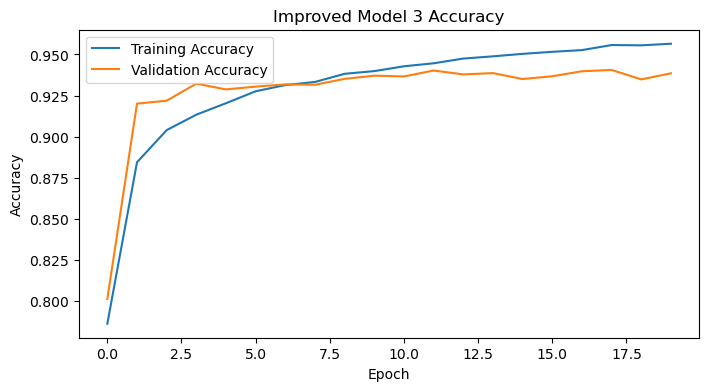

In [49]:
plt.figure(figsize=(8, 4))

plt.plot(improved_history_3.history["accuracy"], label="Training Accuracy")
plt.plot(improved_history_3.history["val_accuracy"], label="Validation Accuracy")

plt.title("Improved Model 3 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


**Reflection:** The accuracy graph for Improved Model 3 shows that both training and validation accuracy increase quickly during the early epochs. After that, validation accuracy stays around 93-94% while training accuracy continues to rise gradually. This means the model is learning well, but the gap between training and validation accuracy increases slightly over time. Batch Normalization and stronger regularisation made training stable, but they did not produce a clear accuracy improvement over the previous models.


#### 6.3.2 Model 3 Loss Graph

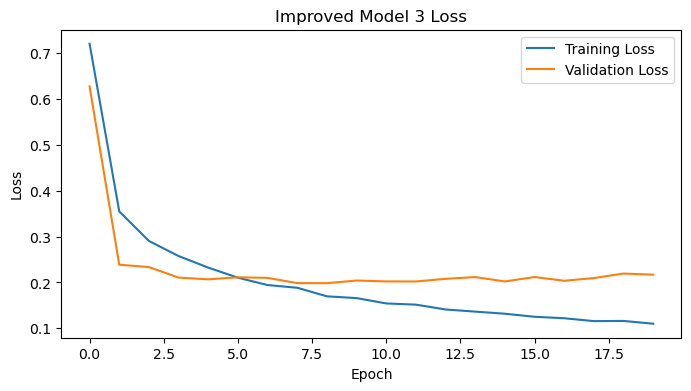

In [50]:
plt.figure(figsize=(8, 4))

plt.plot(improved_history_3.history["loss"], label="Training Loss")
plt.plot(improved_history_3.history["val_loss"], label="Validation Loss")

plt.title("Improved Model 3 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


**Reflection:** The loss graph for Improved Model 3 shows that both training and validation loss decrease sharply at the start, indicating that the model learns useful features quickly. After the early epochs, training loss continues to decrease, but validation loss stays mostly flat and later increases slightly. This suggests mild overfitting. Batch Normalization helped stabilise early training, but the validation loss pattern shows that it did not fully solve the generalisation


#### 6.3.3 Model 3 Evaluation Compared with Previous Models

Improved Model 3 performs better than the baseline but does not clearly outperform Improved Model 1 or Improved Model 2. Although Batch Normalization was expected to stabilise training, the final validation accuracy and loss show only a small difference from Model 2.

This suggests that Batch Normalization and reducing the dense layer size did not solve the main limitation by themselves. The model remains useful as an experiment because it shows that reducing complexity and adding normalisation can control training, but it did not give the clearest improvement.

### 6.4 Improved Model 4: LeakyReLU with Batch Normalization

Improved Model 4 combines the useful ideas tested separately in Models 2 and 3. LeakyReLU was tested because it may improve learning by allowing small negative gradients, while Batch Normalization was tested because it may stabilise training and reduce validation loss fluctuation.

This model checks whether combining both ideas can improve performance more than using either method alone.

In [26]:
improved_model_4 = Sequential()

improved_model_4.add(Conv2D(32, (3, 3), padding="same", input_shape=(28, 28, 1)))
improved_model_4.add(BatchNormalization())
improved_model_4.add(LeakyReLU(alpha=0.1))
improved_model_4.add(MaxPooling2D(pool_size=(2, 2)))

improved_model_4.add(Conv2D(64, (3, 3), padding="same"))
improved_model_4.add(BatchNormalization())
improved_model_4.add(LeakyReLU(alpha=0.1))
improved_model_4.add(MaxPooling2D(pool_size=(2, 2)))

improved_model_4.add(Dropout(0.30))
improved_model_4.add(Flatten())

improved_model_4.add(Dense(384))
improved_model_4.add(BatchNormalization())
improved_model_4.add(LeakyReLU(alpha=0.1))
improved_model_4.add(Dropout(0.35))

improved_model_4.add(Dense(num_classes, activation="softmax"))

improved_model_4.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model_4.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 batch_normalization_4 (Batc  (None, 28, 28, 32)       128       
 hNormalization)                                                 
                                                                 
 leaky_re_lu_8 (LeakyReLU)   (None, 28, 28, 32)        0         
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_5 (Batc  (None, 14, 14, 64)      

**Training setup for Improved Model 4**

Improved Model 4 is trained using the same train-validation split and `batch_size=200` for a fair comparison with Improved Model 1. The architecture combines LeakyReLU and Batch Normalization, so the training results show whether this combined approach improves validation accuracy and loss.

In [27]:
improved_history_4 = improved_model_4.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=200,
    verbose=1
)

Epoch 1/20
311/311 [==============================] - 5s 13ms/step - loss: 0.6074 - accuracy: 0.8150 - val_loss: 6.7545 - val_accuracy: 0.0429
Epoch 2/20
311/311 [==============================] - 4s 11ms/step - loss: 0.3243 - accuracy: 0.8944 - val_loss: 0.2729 - val_accuracy: 0.9143
Epoch 3/20
311/311 [==============================] - 4s 11ms/step - loss: 0.2658 - accuracy: 0.9118 - val_loss: 0.2499 - val_accuracy: 0.9161
Epoch 4/20
311/311 [==============================] - 4s 11ms/step - loss: 0.2359 - accuracy: 0.9205 - val_loss: 0.2042 - val_accuracy: 0.9319
Epoch 5/20
311/311 [==============================] - 4s 11ms/step - loss: 0.2116 - accuracy: 0.9285 - val_loss: 0.1914 - val_accuracy: 0.9334
Epoch 6/20
311/311 [==============================] - 4s 11ms/step - loss: 0.1936 - accuracy: 0.9332 - val_loss: 0.1862 - val_accuracy: 0.9356
Epoch 7/20
311/311 [==============================] - 4s 11ms/step - loss: 0.1809 - accuracy: 0.9380 - val_loss: 0.1837 - val_accuracy: 0.9389

In [28]:
improved_4_val_loss, improved_4_val_accuracy = improved_model_4.evaluate(X_val, y_val, verbose=0)

print("Improved Model 4 Validation Loss: %.4f" % improved_4_val_loss)
print("Improved Model 4 Validation Accuracy: %.2f%%" % (improved_4_val_accuracy * 100))
print("Improved Model 4 Validation Error: %.2f%%" % (100 - improved_4_val_accuracy * 100))

Improved Model 4 Validation Loss: 0.1889
Improved Model 4 Validation Accuracy: 94.34%
Improved Model 4 Validation Error: 5.66%


**Reflection:** Improved Model 4 achieved the best validation result among the first four improved models, with a validation accuracy of 94.34% and validation loss of 0.1889. This improved both accuracy and loss compared with the baseline and the earlier improvement attempts. The result suggests that combining LeakyReLU with Batch Normalization helped the CNN learn more stable and useful visual features.

#### 6.4.1 Model 4 Accuracy Graph

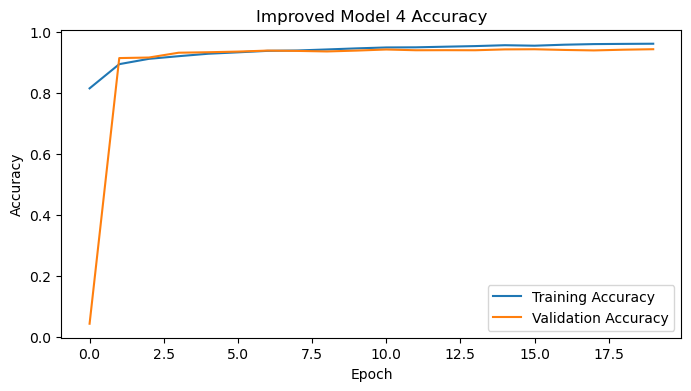

In [51]:
plt.figure(figsize=(8, 4))

plt.plot(improved_history_4.history["accuracy"], label="Training Accuracy")
plt.plot(improved_history_4.history["val_accuracy"], label="Validation Accuracy")

plt.title("Improved Model 4 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


**Reflection:** The accuracy graph for Improved Model 4 shows that both training and validation accuracy improve quickly and remain close after the early epochs. The validation accuracy rises sharply at the beginning and then stays around the mid-90% range, which suggests that the model learns useful features and generalises well. The small gap between training and validation accuracy indicates that the model is not severely overfitting in terms of accuracy, although the curve flattens after the first few epochs, meaning additional epochs give only limited accuracy improvement.


#### 6.4.2 Model 4 Loss Graph

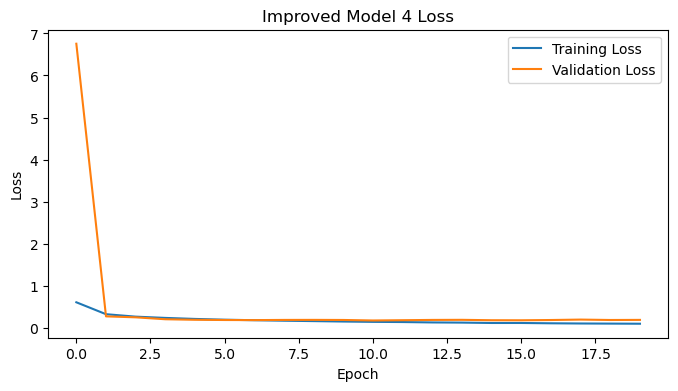

In [52]:
plt.figure(figsize=(8, 4))

plt.plot(improved_history_4.history["loss"], label="Training Loss")
plt.plot(improved_history_4.history["val_loss"], label="Validation Loss")

plt.title("Improved Model 4 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


**Reflection:** The loss graph for Improved Model 4 shows a very large validation loss at the first epoch, followed by a sharp drop after the model begins learning useful patterns. After the early epochs, both training and validation loss remain low and relatively stable. The training loss continues to decrease slightly, while validation loss stays mostly flat with small fluctuations. This suggests that the model generalises better than earlier models, although training for many more epochs may not provide much additional benefit once the validation loss has stabilised.


#### 6.4.3 Model 4 Evaluation Compared with Previous Models

Improved Model 4 performs best among the first four improved models. It achieves higher validation accuracy and lower validation loss than the baseline, Model 1, Model 2, and Model 3. This suggests that combining LeakyReLU with Batch Normalization is more effective than using either idea separately.

The result shows that the model benefits from both more stable activations and a non-zero gradient for negative activation values. Because this model improves both accuracy and loss, it becomes the strongest candidate before testing data augmentation and dropout tuning.

### 6.5 Model Comparison

The validation results of the baseline and improved models are compared using validation loss, validation accuracy, and validation error. This comparison helps identify which model change gave the clearest improvement and whether the improvement affected both accuracy and loss.

In [53]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Improved Model 1",
        "Improved Model 2",
        "Improved Model 3",
        "Improved Model 4"
    ],
    "Validation Loss": [
        scores[0],
        improved_1_val_loss,
        improved_2_val_loss,
        improved_3_val_loss,
        improved_4_val_loss
    ],
    "Validation Accuracy": [
        scores[1],
        improved_1_val_accuracy,
        improved_2_val_accuracy,
        improved_3_val_accuracy,
        improved_4_val_accuracy
    ]
})

model_comparison["Validation Accuracy (%)"] = model_comparison["Validation Accuracy"] * 100
model_comparison["Validation Error (%)"] = 100 - model_comparison["Validation Accuracy (%)"]

model_comparison


,Model,Validation Loss,Validation Accuracy,Validation Accuracy (%),Validation Error (%)
0,Baseline,0.211873,0.929730,92.972970,7.027030
1,Improved Model 1,0.206405,0.939752,93.975228,6.024772
2,Improved Model 2,0.215636,0.938851,93.885136,6.114864
3,Improved Model 3,0.216958,0.938514,93.851352,6.148648
4,Improved Model 4,0.188904,0.943356,94.335586,5.664414


**Reflection:** The model comparison table shows that all improved models performed better than the baseline in validation accuracy. Improved Model 1 gave a clear improvement over the baseline, increasing validation accuracy from 92.97% to 93.98%. Improved Models 2 and 3 were still better than the baseline, but they did not outperform Model 1, showing that LeakyReLU alone and Batch Normalization alone did not give the clearest benefit.

Improved Model 4 performed the best overall, achieving the highest validation accuracy of 94.34% and the lowest validation loss of 0.1889. This suggests that combining LeakyReLU with Batch Normalization was more effective than applying those changes separately. Therefore, Improved Model 4 is the strongest model before testing data augmentation and dropout tuning.


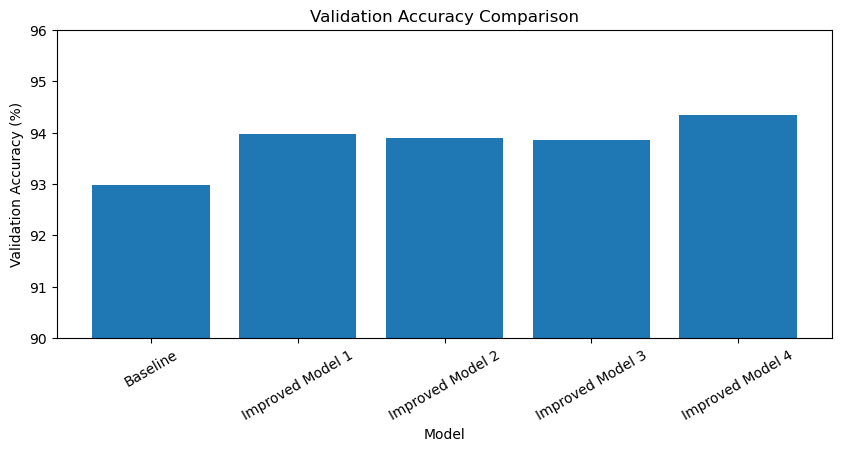

In [54]:
plt.figure(figsize=(10, 4))
plt.bar(model_comparison["Model"], model_comparison["Validation Accuracy (%)"])
plt.title("Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.xticks(rotation=30)
plt.ylim(90, 96)
plt.show()

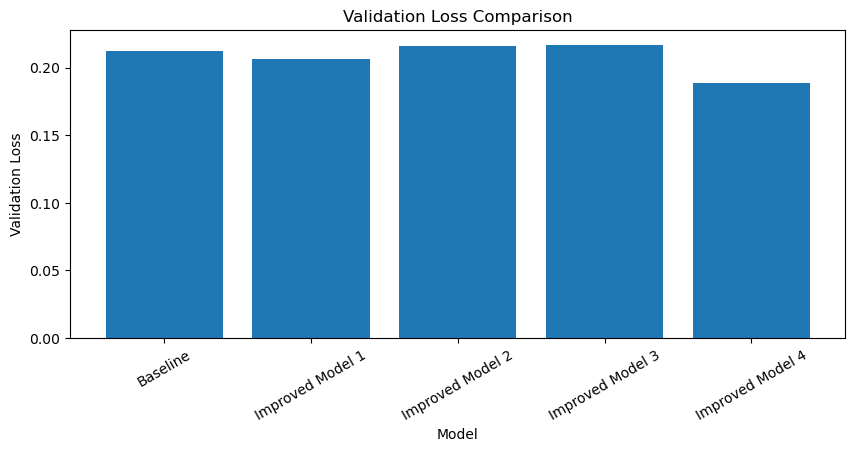

In [55]:
plt.figure(figsize=(10, 4))
plt.bar(model_comparison["Model"], model_comparison["Validation Loss"])
plt.title("Validation Loss Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Loss")
plt.xticks(rotation=30)
plt.show()


**Reflection:** The model comparison shows that the architecture changes improved performance over the baseline. Improved Model 4 gives the strongest result among the first four improved models because it achieves both the highest validation accuracy and the lowest validation loss. This suggests that combining LeakyReLU with Batch Normalization was more effective than using either approach separately.
**So for later adjustments we will be doing over model 4**.

### 6.6 Data Augmentation

Static data augmentation is tested after the model comparison to see whether adding more training variation can improve the best architecture further.

The transformations are kept mild: small rotation, small translation, and small zoom. These are suitable for handwritten characters because real handwriting can vary slightly in angle, position, and size. Strong transformations are avoided because they may distort letters or change their meaning.

In [13]:
static_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.08),
], name="static_augmentation")

Only a subset of the training data is augmented to keep the training time practical. This still increases the amount of training data while avoiding the heavy cost of duplicating the entire training set.

In [14]:
aug_sample_size = 10000
sample_indices = np.random.choice(len(X_train), size=aug_sample_size, replace=False)

augmented_batches = []
batch_size_aug = 1000

for start in range(0, aug_sample_size, batch_size_aug):
    batch_indices = sample_indices[start:start + batch_size_aug]

    X_batch_augmented = static_augmentation(
        X_train[batch_indices],
        training=True
    ).numpy()

    augmented_batches.append(X_batch_augmented)

    print("Augmented:", min(start + batch_size_aug, aug_sample_size), "/", aug_sample_size)

X_train_augmented = np.concatenate(augmented_batches, axis=0)
y_train_augmented = y_train[sample_indices]

X_train_static_aug = np.concatenate([X_train, X_train_augmented], axis=0)
y_train_static_aug = np.concatenate([y_train, y_train_augmented], axis=0)

print("Original X_train:", X_train.shape)
print("Augmented X_train:", X_train_augmented.shape)
print("Combined X_train:", X_train_static_aug.shape)

print("Original y_train:", y_train.shape)
print("Combined y_train:", y_train_static_aug.shape)


Augmented: 1000 / 10000
Augmented: 2000 / 10000
Augmented: 3000 / 10000
Augmented: 4000 / 10000
Augmented: 5000 / 10000
Augmented: 6000 / 10000
Augmented: 7000 / 10000
Augmented: 8000 / 10000
Augmented: 9000 / 10000
Augmented: 10000 / 10000
Original X_train: (62160, 28, 28, 1)
Augmented X_train: (10000, 28, 28, 1)
Combined X_train: (72160, 28, 28, 1)
Original y_train: (62160,)
Combined y_train: (72160,)


The static augmentation model uses the same main architecture as Improved Model 4. This keeps the model structure controlled, so the main difference being tested is the additional augmented training data.

In [15]:
static_aug_model = Sequential()

static_aug_model.add(Conv2D(32, (3, 3), padding="same", input_shape=(28, 28, 1)))
static_aug_model.add(BatchNormalization())
static_aug_model.add(LeakyReLU(alpha=0.1))
static_aug_model.add(MaxPooling2D(pool_size=(2, 2)))

static_aug_model.add(Conv2D(64, (3, 3), padding="same"))
static_aug_model.add(BatchNormalization())
static_aug_model.add(LeakyReLU(alpha=0.1))
static_aug_model.add(MaxPooling2D(pool_size=(2, 2)))

static_aug_model.add(Dropout(0.30))
static_aug_model.add(Flatten())

static_aug_model.add(Dense(384))
static_aug_model.add(BatchNormalization())
static_aug_model.add(LeakyReLU(alpha=0.1))
static_aug_model.add(Dropout(0.35))

static_aug_model.add(Dense(num_classes, activation="softmax"))

static_aug_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

static_aug_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 32)       128       
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 28, 28, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 14, 14, 64)       2

**Training setup for static augmentation model**

The model is trained using the combined original and augmented training set, while the validation set remains unchanged. This keeps evaluation fair because validation performance is measured on real, non-augmented samples.

In [16]:
static_aug_history = static_aug_model.fit(
    X_train_static_aug,
    y_train_static_aug,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=200,
    verbose=1
)


Epoch 1/20
361/361 [==============================] - 18s 14ms/step - loss: 0.6469 - accuracy: 0.8029 - val_loss: 1.0054 - val_accuracy: 0.7322
Epoch 2/20
361/361 [==============================] - 5s 13ms/step - loss: 0.3459 - accuracy: 0.8870 - val_loss: 0.2830 - val_accuracy: 0.9074
Epoch 3/20
361/361 [==============================] - 5s 14ms/step - loss: 0.2878 - accuracy: 0.9053 - val_loss: 0.2123 - val_accuracy: 0.9296
Epoch 4/20
361/361 [==============================] - 5s 13ms/step - loss: 0.2545 - accuracy: 0.9139 - val_loss: 0.2116 - val_accuracy: 0.9302
Epoch 5/20
361/361 [==============================] - 5s 13ms/step - loss: 0.2280 - accuracy: 0.9227 - val_loss: 0.1995 - val_accuracy: 0.9390
Epoch 6/20
361/361 [==============================] - 5s 13ms/step - loss: 0.2078 - accuracy: 0.9283 - val_loss: 0.1947 - val_accuracy: 0.9350
Epoch 7/20
361/361 [==============================] - 5s 13ms/step - loss: 0.1939 - accuracy: 0.9322 - val_loss: 0.1791 - val_accuracy: 0.939

In [17]:
static_aug_val_loss, static_aug_val_accuracy = static_aug_model.evaluate(X_val, y_val, verbose=0)

print("Static Augmentation Model Validation Loss: %.4f" % static_aug_val_loss)
print("Static Augmentation Model Validation Accuracy: %.2f%%" % (static_aug_val_accuracy * 100))
print("Static Augmentation Model Validation Error: %.2f%%" % (100 - static_aug_val_accuracy * 100))


Static Augmentation Model Validation Loss: 0.1948
Static Augmentation Model Validation Accuracy: 94.13%
Static Augmentation Model Validation Error: 5.87%


**Reflection:** Static augmentation increased the amount of training data, but it did not outperform Improved Model 4. This suggests that the extra augmented samples did not provide a large enough benefit to overcome the additional training cost. Since the original dataset is already large and balanced, the architecture and regularisation changes had a clearer impact than static augmentation in this experiment.

#### 6.6.1 Static Augmentation Accuracy Graph

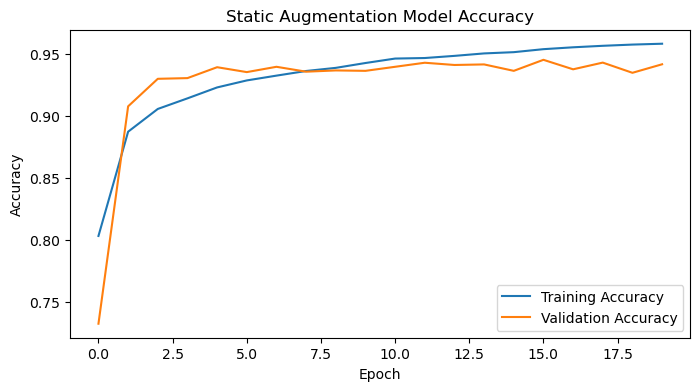

In [18]:
plt.figure(figsize=(8, 4))

plt.plot(static_aug_history.history["accuracy"], label="Training Accuracy")
plt.plot(static_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Static Augmentation Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


**Reflection:** The static augmentation accuracy graph shows that both training and validation accuracy improve quickly in the early epochs. Training accuracy continues to increase steadily, while validation accuracy stays around 94% after the first few epochs and fluctuates slightly. This suggests that the augmented data helps the model learn more training variation, but the validation performance does not improve much beyond Improved Model 4. The widening gap between training and validation accuracy also suggests mild overfitting as training continues.


#### 6.6.2 Static Augmentation Loss Graph

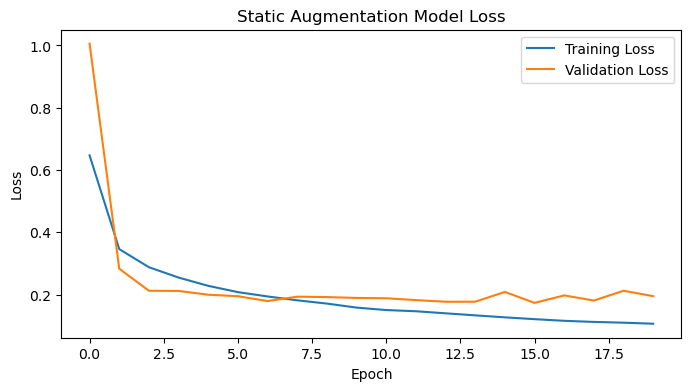

In [19]:
plt.figure(figsize=(8, 4))

plt.plot(static_aug_history.history["loss"], label="Training Loss")
plt.plot(static_aug_history.history["val_loss"], label="Validation Loss")

plt.title("Static Augmentation Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


**Reflection:** The static augmentation loss graph shows that both training and validation loss decrease sharply during the early epochs, meaning the model quickly learns useful patterns from the original and augmented images.

After the first few epochs, training loss continues to decrease steadily, but validation loss becomes flatter and starts to fluctuate slightly. This suggests that the model is still improving on the training data, but the extra improvement does not fully transfer to unseen validation data.

The validation loss remains around a reasonable level, so the model is not failing, but the small fluctuations show that static augmentation did not give a clear improvement over the best non-augmented model. The main trade off is that augmentation increased training data and training time, but only gave limited validation benefit.


#### Further Evaluations
After applying static data augmentation, further evaluation graphs and confusion analysis were added to check whether the extra generated training images changed the model behaviour. Since augmentation increases the variation of the training data, it is important to confirm whether the model improves only in overall accuracy, or whether it also reduces specific letter confusions.

The confusion matrix and confused-class inspection help show whether augmentation made the model better at handling visually similar letters such as I/L, G/Q, and U/V. This is useful because a higher validation accuracy alone does not explain which classes improved or whether any new confusion patterns appeared after training with augmented data.


#### 6.6.3 Static Augmentation Confusion Matrix

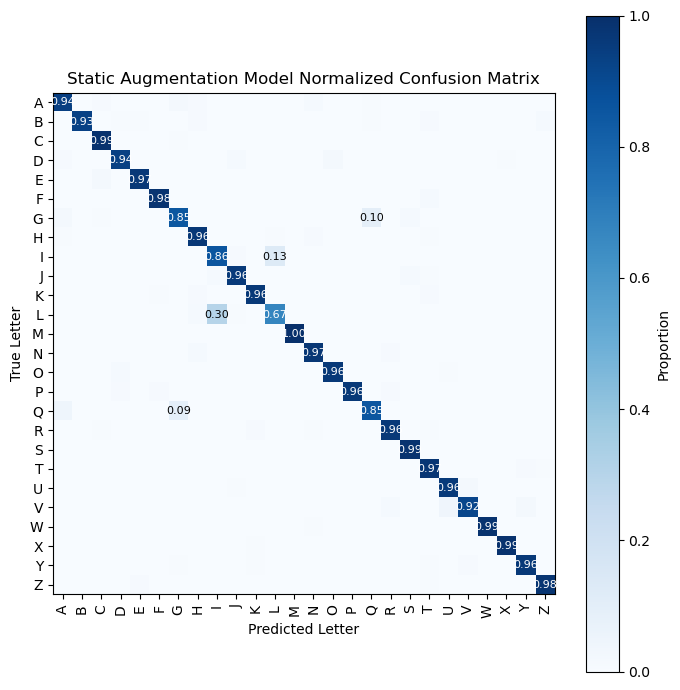

In [22]:
class_names = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

# Predict validation classes for static augmentation model
y_val_pred_probs_static_aug = static_aug_model.predict(X_val, verbose=0)
y_val_pred_static_aug = np.argmax(y_val_pred_probs_static_aug, axis=1)

# Create confusion matrix
cm_static_aug = confusion_matrix(y_val, y_val_pred_static_aug)

# Normalize by true class row
cm_static_aug_normalized = cm_static_aug.astype("float") / cm_static_aug.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 7))
plt.imshow(cm_static_aug_normalized, cmap="Blues", vmin=0, vmax=1)

plt.title("Static Augmentation Model Normalized Confusion Matrix")
plt.xlabel("Predicted Letter")
plt.ylabel("True Letter")

plt.xticks(range(26), class_names, rotation=90)
plt.yticks(range(26), class_names)

plt.colorbar(label="Proportion")

for i in range(26):
    for j in range(26):
        value = cm_static_aug_normalized[i, j]
        if value >= 0.05:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if value > 0.5 else "black",
                fontsize=8
            )

plt.tight_layout()
plt.show()


The static augmentation confusion matrix shows that most letters are still correctly classified, as shown by the strong diagonal values. This means the augmented model is generally learning the correct letter patterns.

However, some confusion remains for visually similar letters. The clearest issue is `L` being predicted as `I`, where about 30% of true `L` samples are classified as `I`. There are also smaller confusions such as `I` predicted as `L`, `G` predicted as `Q`, and `Q` predicted as `G`. These errors are reasonable because these handwritten letters can look very similar depending on writing style.

Compared with the baseline confusion analysis, static augmentation did not fully remove the main confused letter pairs. This suggests that simply adding mild rotated, shifted, and zoomed images improves general variation, but it may not be enough to separate letters with very similar shapes.


#### 6.6.4 Static Augmentation Common Confused Classes

In [23]:
cm_static_aug_no_diag = cm_static_aug.copy()
np.fill_diagonal(cm_static_aug_no_diag, 0)

confusions_static_aug = []

for true_idx in range(26):
    for pred_idx in range(26):
        count = cm_static_aug_no_diag[true_idx, pred_idx]
        if count > 0:
            confusions_static_aug.append((class_names[true_idx], class_names[pred_idx], count))

confusions_static_aug = sorted(confusions_static_aug, key=lambda x: x[2], reverse=True)

print("Top 10 Confused Letter Pairs for Static Augmentation Model")
for true_letter, pred_letter, count in confusions_static_aug[:10]:
    print(f"True {true_letter} predicted as {pred_letter}: {count} times")


Top 10 Confused Letter Pairs for Static Augmentation Model
True L predicted as I: 102 times
True I predicted as L: 43 times
True G predicted as Q: 33 times
True Q predicted as G: 32 times
True Q predicted as A: 15 times
True V predicted as U: 14 times
True E predicted as C: 8 times
True D predicted as O: 7 times
True U predicted as V: 7 times
True A predicted as G: 6 times


**Reflection:** The static augmentation model still confuses visually similar letters such as `I/L`, `G/Q`, and `U/V`. This shows that although augmentation adds more training variation, it does not fully solve the fine-grained differences between similar handwritten characters.

#### 6.6.5 Static Augmentation Model Evaluation

The static augmentation model was evaluated to check whether adding extra transformed training images improved the model performance. The augmented dataset included mild rotations, translations, and zooms, which are reasonable for handwritten letters because real handwriting can vary slightly in position, size, and angle.

However, the validation result did not improve compared with the best non-augmented model. The accuracy remained close, but the validation loss and confusion analysis showed that the main difficult letter pairs, such as `I/L`, `G/Q`, and `U/V`, were still confused. This means the extra augmented images did not give a clear benefit for this dataset.

Because the augmented model increased training time and data size without improving validation performance, it will not be used for the later final model selection. The later steps will continue with the best non-augmented model instead, as it gives better performance with lower training cost.


### 6.7 Dropout Tuned Model with Early Stopping

After static augmentation did not clearly improve validation performance, the next improvement focuses on reducing overfitting in the best non-augmented architecture. The model keeps the main structure from Improved Model 4, but increases dropout slightly and adds early stopping so training can stop when validation loss no longer improves.


#### 6.7.1 Early stopping setup

Early stopping monitors validation loss because validation loss shows whether the model is still improving on unseen data. A patience value of 3 allows the model a few epochs to recover from small fluctuations, while restore_best_weights=True keeps the weights from the epoch with the best validation loss.


In [17]:
dropout_tuned_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

**Model design**

This model is based on Improved Model 4 because that version gave the best validation accuracy and loss among the first four improved models. Dropout is increased from 0.30 to 0.35 after the convolution blocks and from 0.35 to 0.40 after the dense layer to reduce overfitting while keeping the same feature extraction approach.


In [12]:
dropout_tuned_model = Sequential()

dropout_tuned_model.add(Conv2D(32, (3, 3), padding="same", input_shape=(28, 28, 1)))
dropout_tuned_model.add(BatchNormalization())
dropout_tuned_model.add(LeakyReLU(alpha=0.1))
dropout_tuned_model.add(MaxPooling2D(pool_size=(2, 2)))

dropout_tuned_model.add(Conv2D(64, (3, 3), padding="same"))
dropout_tuned_model.add(BatchNormalization())
dropout_tuned_model.add(LeakyReLU(alpha=0.1))
dropout_tuned_model.add(MaxPooling2D(pool_size=(2, 2)))

dropout_tuned_model.add(Dropout(0.35))
dropout_tuned_model.add(Flatten())

dropout_tuned_model.add(Dense(384))
dropout_tuned_model.add(BatchNormalization())
dropout_tuned_model.add(LeakyReLU(alpha=0.1))
dropout_tuned_model.add(Dropout(0.40))

dropout_tuned_model.add(Dense(num_classes, activation="softmax"))

dropout_tuned_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dropout_tuned_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 32)       128       
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 28, 28, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 14, 14, 64)       2

**Training setup for dropout tuned model**

The model is trained on the original training set instead of the augmented set so the effect of dropout and early stopping can be compared more directly with Improved Model 4. The maximum epoch count is increased to 30, but early stopping can end training earlier if validation loss stops improving.


In [18]:
dropout_tuned_history = dropout_tuned_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=200,
    callbacks=[dropout_tuned_early_stop],
    verbose=1
)


Epoch 1/30
311/311 [==============================] - 4s 12ms/step - loss: 0.1096 - accuracy: 0.9577 - val_loss: 0.1874 - val_accuracy: 0.9413
Epoch 2/30
311/311 [==============================] - 3s 11ms/step - loss: 0.1089 - accuracy: 0.9578 - val_loss: 0.1853 - val_accuracy: 0.9447
Epoch 3/30
311/311 [==============================] - 4s 12ms/step - loss: 0.1070 - accuracy: 0.9585 - val_loss: 0.1973 - val_accuracy: 0.9407
Epoch 4/30
311/311 [==============================] - 4s 12ms/step - loss: 0.1028 - accuracy: 0.9600 - val_loss: 0.1798 - val_accuracy: 0.9443
Epoch 5/30
311/311 [==============================] - 3s 11ms/step - loss: 0.1034 - accuracy: 0.9590 - val_loss: 0.1810 - val_accuracy: 0.9435
Epoch 6/30
311/311 [==============================] - 3s 11ms/step - loss: 0.0993 - accuracy: 0.9604 - val_loss: 0.1932 - val_accuracy: 0.9399
Epoch 7/30
311/311 [==============================] - 3s 11ms/step - loss: 0.0985 - accuracy: 0.9611 - val_loss: 0.1919 - val_accuracy: 0.9420

**Validation evaluation**

The dropout tuned model is evaluated on the validation set after training. These results are used for model comparison only, while the test set should still be kept for the final selected model evaluation.


In [19]:
dropout_tuned_val_loss, dropout_tuned_val_accuracy = dropout_tuned_model.evaluate(X_val, y_val, verbose=0)

print("Dropout Tuned Model Validation Loss: %.4f" % dropout_tuned_val_loss)
print("Dropout Tuned Model Validation Accuracy: %.2f%%" % (dropout_tuned_val_accuracy * 100))
print("Dropout Tuned Model Validation Error: %.2f%%" % (100 - dropout_tuned_val_accuracy * 100))


Dropout Tuned Model Validation Loss: 0.1798
Dropout Tuned Model Validation Accuracy: 94.43%
Dropout Tuned Model Validation Error: 5.57%


**Reflection:** The dropout tuned model checks whether stronger regularisation can reduce the validation loss fluctuations seen in earlier models. If its validation accuracy and loss improve over Improved Model 4, this suggests the previous best model still had some overfitting and benefited from slightly higher dropout and early stopping. If the result is similar, it still shows that the model has reached a stable performance range and that further gains may need better data handling or class-specific error analysis rather than only architecture changes.


### 7. Final Model Testing and Saving

The final model is rebuilt using the same architecture as the best validation model. Since the previous trained weights were not saved, this final model is trained again and this run is used as the final reported model. The weights are saved immediately after training so the trained model can be reused later without retraining.


#### 7.1 Build Final Model

The final model uses the dropout-tuned architecture because it gave the strongest validation result. It keeps the LeakyReLU and Batch Normalization structure from Improved Model 4, with slightly higher dropout to reduce overfitting.


In [23]:
final_model = Sequential()

final_model.add(Conv2D(32, (3, 3), padding="same", input_shape=(28, 28, 1)))
final_model.add(BatchNormalization())
final_model.add(LeakyReLU(alpha=0.1))
final_model.add(MaxPooling2D(pool_size=(2, 2)))

final_model.add(Conv2D(64, (3, 3), padding="same"))
final_model.add(BatchNormalization())
final_model.add(LeakyReLU(alpha=0.1))
final_model.add(MaxPooling2D(pool_size=(2, 2)))

final_model.add(Dropout(0.35))
final_model.add(Flatten())

final_model.add(Dense(384))
final_model.add(BatchNormalization())
final_model.add(LeakyReLU(alpha=0.1))
final_model.add(Dropout(0.40))

final_model.add(Dense(num_classes, activation="softmax"))

final_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 32)       128       
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 28, 28, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 14, 14, 64)       2

#### 7.2 Train Final Model

Early stopping is used in the final training run to prevent unnecessary training after validation loss stops improving. The validation set is still used only to monitor training, while the test set is kept untouched until the final evaluation.


In [25]:
final_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=200,
    callbacks=[final_early_stop],
    verbose=1
)


Epoch 1/30
311/311 [==============================] - 5s 14ms/step - loss: 0.1952 - accuracy: 0.9320 - val_loss: 0.1884 - val_accuracy: 0.9365
Epoch 2/30
311/311 [==============================] - 4s 14ms/step - loss: 0.1817 - accuracy: 0.9365 - val_loss: 0.2362 - val_accuracy: 0.9215
Epoch 3/30
311/311 [==============================] - 4s 14ms/step - loss: 0.1687 - accuracy: 0.9402 - val_loss: 0.1757 - val_accuracy: 0.9417
Epoch 4/30
311/311 [==============================] - 4s 14ms/step - loss: 0.1635 - accuracy: 0.9410 - val_loss: 0.1845 - val_accuracy: 0.9394
Epoch 5/30
311/311 [==============================] - 4s 14ms/step - loss: 0.1516 - accuracy: 0.9455 - val_loss: 0.1919 - val_accuracy: 0.9359
Epoch 6/30
311/311 [==============================] - 4s 14ms/step - loss: 0.1483 - accuracy: 0.9458 - val_loss: 0.1819 - val_accuracy: 0.9405


#### 7.3 Final Test Evaluation

The test set is used only after the final model has been selected and trained. This gives a fair estimate of how well the selected model generalises to unseen data, because the test data was not used during model improvement or model selection.


In [26]:
final_test_loss, final_test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)

print("Final Test Loss: %.4f" % final_test_loss)
print("Final Test Accuracy: %.2f%%" % (final_test_accuracy * 100))
print("Final Test Error: %.2f%%" % (100 - final_test_accuracy * 100))


Final Test Loss: 0.1763
Final Test Accuracy: 94.16%
Final Test Error: 5.84%


**Reflection:** The final model achieved a test accuracy of 94.16% with a test loss of 0.1763, showing that it performs well on unseen data. Since the test set was not used during training or model selection, this result gives a fair estimate of the model's generalisation performance.

The test error is 5.84%, meaning the model still misclassifies a small portion of handwritten letters. This is expected because some letters have very similar handwritten shapes, especially when the writing style is unclear or inconsistent. Overall, the final model shows strong performance while still leaving room for improvement in difficult letter pairs.


#### 7.4 Overall Test Metrics

The final model is evaluated using the test set after model selection is complete. This section reports overall loss, accuracy, error rate, precision, recall, F1-score, and the number of correct and incorrect predictions.


In [29]:
class_names = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

# Evaluate final model on test set
final_test_loss, final_test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    batch_size=512,
    verbose=0
)

# Predict test set
final_test_pred_probs = final_model.predict(X_test, batch_size=512, verbose=0)
final_test_pred = np.argmax(final_test_pred_probs, axis=1)

# Main metrics
final_accuracy = accuracy_score(y_test, final_test_pred)
final_precision = precision_score(y_test, final_test_pred, average="macro")
final_recall = recall_score(y_test, final_test_pred, average="macro")
final_f1 = f1_score(y_test, final_test_pred, average="macro")
final_weighted_f1 = f1_score(y_test, final_test_pred, average="weighted")

# Prediction counts
final_correct = np.sum(final_test_pred == y_test)
final_wrong = np.sum(final_test_pred != y_test)
final_total = len(y_test)

print("Final Test Evaluation")
print("---------------------")
print("Test Loss: %.4f" % final_test_loss)
print("Test Accuracy: %.4f" % final_accuracy)
print("Test Accuracy: %.2f%%" % (final_accuracy * 100))
print("Test Error: %.2f%%" % (100 - final_accuracy * 100))
print("Macro Precision: %.4f" % final_precision)
print("Macro Recall: %.4f" % final_recall)
print("Macro F1-score: %.4f" % final_f1)
print("Weighted F1-score: %.4f" % final_weighted_f1)
print("Total Test Images:", final_total)
print("Correct Predictions:", final_correct)
print("Wrong Predictions:", final_wrong)
print("Correct Percentage: %.2f%%" % ((final_correct / final_total) * 100))
print("Wrong Percentage: %.2f%%" % ((final_wrong / final_total) * 100))


Final Test Evaluation
---------------------
Test Loss: 0.1763
Test Accuracy: 0.9416
Test Accuracy: 94.16%
Test Error: 5.84%
Macro Precision: 0.9423
Macro Recall: 0.9416
Macro F1-score: 0.9418
Weighted F1-score: 0.9418
Total Test Images: 17760
Correct Predictions: 16723
Wrong Predictions: 1037
Correct Percentage: 94.16%
Wrong Percentage: 5.84%


**Reflection:** The final test evaluation shows that the selected model generalises well to unseen data, achieving 94.16% accuracy on 17,760 test images. Out of these, 16,723 images were classified correctly and 1,037 were misclassified, giving a test error of 5.84%.

The macro precision, macro recall, macro F1-score, and weighted F1-score are all around 0.94. This is a positive sign because it shows the model is not only performing well overall, but is also performing consistently across the 26 letter classes. The macro and weighted F1-scores are almost the same, which also suggests that the class distribution is balanced and no single class is dominating the evaluation result.

Overall, the final model gives strong performance, but the remaining 5.84% error shows that there are still difficult handwritten samples that the model confuses, especially between letters with similar shapes.


#### 7.5 Class-Level Performance Table

A class-level table is used to inspect the final model performance for each letter from A to Z. Class accuracy, precision, recall, F1-score, and support help identify weaker letters that may be hidden by the overall test accuracy.


In [34]:
# Class-level performance table
report = classification_report(
    y_test,
    final_test_pred,
    target_names=class_names,
    output_dict=True
)

class_performance_df = pd.DataFrame(report).T.loc[
    class_names,
    ["precision", "recall", "f1-score", "support"]
]

# Add class accuracy
class_accuracies = []

for class_index in range(26):
    class_mask = y_test == class_index
    class_accuracy = np.mean(final_test_pred[class_mask] == y_test[class_mask])
    class_accuracies.append(class_accuracy)

class_performance_df["class_accuracy"] = class_accuracies

# Reorder columns
class_performance_df = class_performance_df[
    ["class_accuracy", "precision", "recall", "f1-score", "support"]
]

# Show weakest classes first
class_performance_df.sort_values("class_accuracy")


,class_accuracy,precision,recall,f1-score,support
I,0.737226,0.767477,0.737226,0.752048,685.0
L,0.796486,0.746228,0.796486,0.770538,683.0
G,0.862629,0.860088,0.862629,0.861357,677.0
Q,0.880640,0.869253,0.880640,0.874910,687.0
J,0.930984,0.964992,0.930984,0.947683,681.0
R,0.938596,0.975684,0.938596,0.956781,684.0
U,0.940058,0.935953,0.940058,0.938001,684.0
Y,0.942113,0.964444,0.942113,0.953148,691.0
H,0.944526,0.975867,0.944526,0.959941,685.0
A,0.948454,0.949853,0.948454,0.949153,679.0


**Reflection:** The class-level performance table shows that the final model performs strongly for most letters, with many classes achieving accuracy and F1-scores above 0.95. This supports the overall test accuracy result and shows that the model is generally reliable across the alphabet.

The weakest classes are `I`, `L`, `G`, and `Q`. The lowest performance is for `I`, with a class accuracy of 0.7372 and F1-score of 0.7520, followed by `L` with a class accuracy of 0.7965 and F1-score of 0.7705. This suggests that the model still struggles with letters that can look very similar in handwritten form, especially `I` and `L`.

Some classes such as `O`, `E`, `P`, `Z`, `X`, and `W` perform very well, with high class accuracy and strong F1-scores. Overall, the table shows that the final model is effective, but the remaining errors are concentrated in a few visually similar classes rather than spread evenly across all letters.


#### 7.6 Class-Level Accuracy and F1-score Chart

The class-level accuracy and F1-score chart gives a visual comparison of performance across all letters. This makes it easier to identify which classes are consistently strong and which classes need closer inspection.


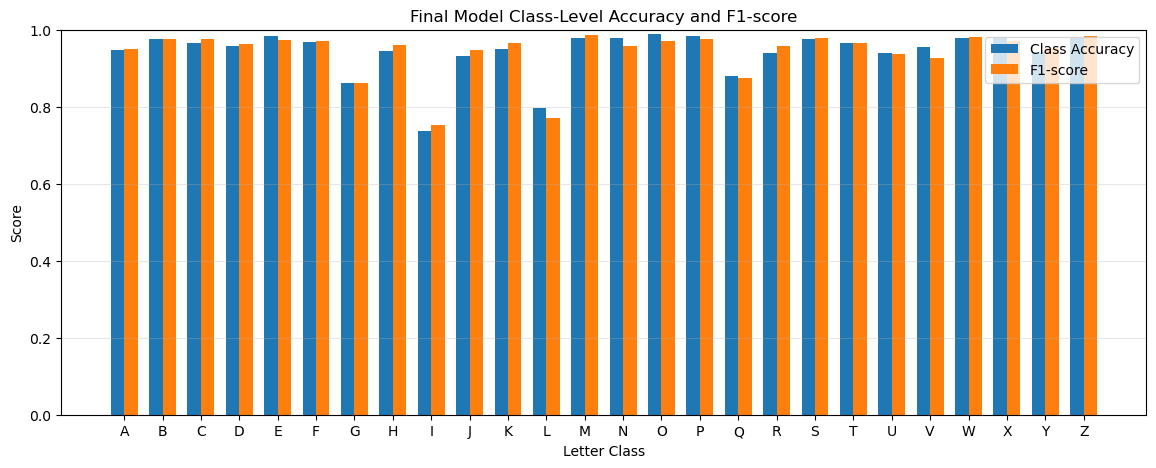

In [35]:
# Class-level accuracy and F1-score chart
plt.figure(figsize=(14, 5))

x = np.arange(len(class_names))
width = 0.35

plt.bar(x - width/2, class_performance_df["class_accuracy"], width, label="Class Accuracy")
plt.bar(x + width/2, class_performance_df["f1-score"], width, label="F1-score")

plt.title("Final Model Class-Level Accuracy and F1-score")
plt.xlabel("Letter Class")
plt.ylabel("Score")
plt.xticks(x, class_names)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()


**Reflection:** The class-level accuracy and F1-score chart shows that the final model performs well for most letters, with many classes scoring close to 1.0. This means the model is generally strong across the alphabet rather than only performing well on a few classes.

The weakest bars are for `I`, `L`, `G`, and `Q`, which matches the class-level performance table. `I` and `L` are especially low compared with the other letters, showing that these two classes remain the main weakness of the final model. This is likely because handwritten `I` and `L` can both appear as simple vertical strokes.

The close alignment between class accuracy and F1-score for most letters suggests that the model has balanced precision and recall across many classes. Overall, the chart confirms that the final model performs strongly, but still struggles with a small number of visually similar handwritten letters.


#### 7.7 Normalized Confusion Matrix

The normalized confusion matrix shows prediction proportions for each true letter class. The diagonal values represent correct predictions, while the off-diagonal values show where the final model confuses one letter with another.


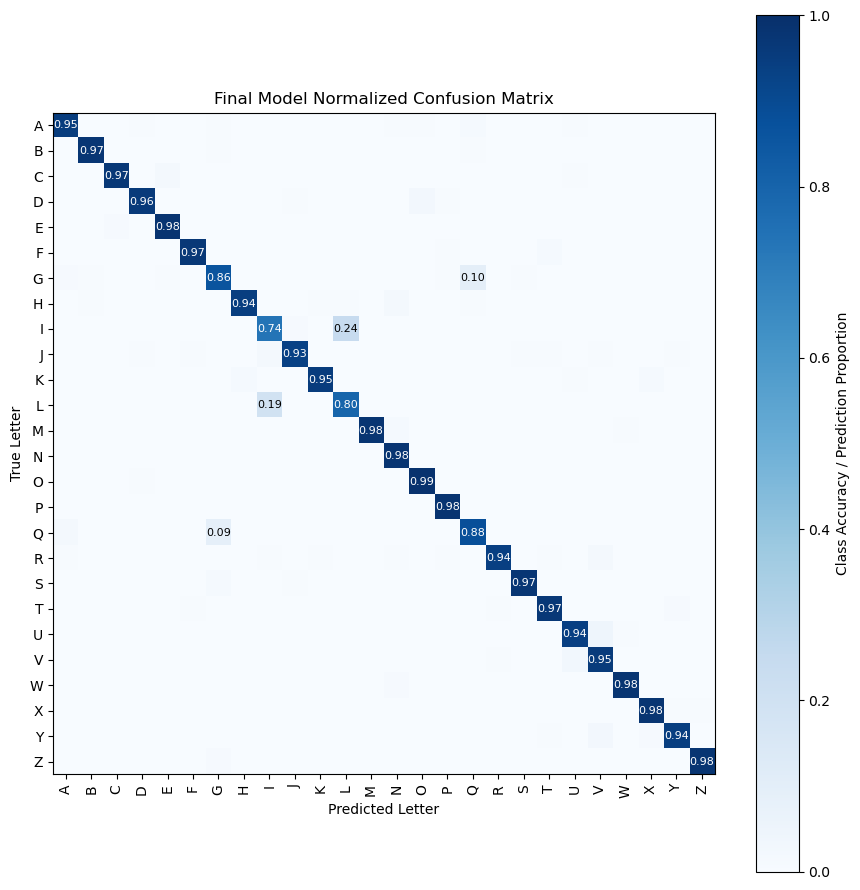

In [36]:
# Normalized confusion matrix
final_cm = confusion_matrix(y_test, final_test_pred)

final_cm_normalized = final_cm.astype("float") / final_cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 9))
plt.imshow(final_cm_normalized, cmap="Blues", vmin=0, vmax=1)

plt.title("Final Model Normalized Confusion Matrix")
plt.xlabel("Predicted Letter")
plt.ylabel("True Letter")

plt.xticks(range(26), class_names, rotation=90)
plt.yticks(range(26), class_names)

plt.colorbar(label="Class Accuracy / Prediction Proportion")

for i in range(26):
    for j in range(26):
        value = final_cm_normalized[i, j]
        if value >= 0.05:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if value > 0.5 else "black",
                fontsize=8
            )

plt.tight_layout()
plt.show()


**Reflection:** The normalized confusion matrix shows strong diagonal values for most letters, which confirms that the final model correctly classifies the majority of test samples across the 26 classes. Many letters such as `B`, `E`, `M`, `O`, `P`, `W`, `X`, and `Z` have very high correct prediction proportions.

The main remaining errors are concentrated in a few visually similar classes. The clearest confusion is between `I` and `L`, where some true `I` samples are predicted as `L`, and some true `L` samples are predicted as `I`. There is also visible confusion between `G` and `Q`, which is expected because both letters can have a round shape with a small tail in handwriting.

Overall, the confusion matrix supports the class-level performance results. The final model performs well generally, but its remaining weakness is distinguishing handwritten letters with very similar shapes.


#### 7.8 Top Confused Letter Pairs

The diagonal values are removed from the confusion matrix so that only incorrect predictions remain. Sorting these errors shows the most common letter pairs that the final model still confuses.


In [37]:
# Top confused letter pairs
final_cm_no_diag = final_cm.copy()
np.fill_diagonal(final_cm_no_diag, 0)

confused_pairs = []

for true_idx in range(26):
    for pred_idx in range(26):
        count = final_cm_no_diag[true_idx, pred_idx]
        if count > 0:
            confused_pairs.append({
                "True Letter": class_names[true_idx],
                "Predicted Letter": class_names[pred_idx],
                "Count": count
            })

confused_pairs_df = pd.DataFrame(confused_pairs)
confused_pairs_df = confused_pairs_df.sort_values("Count", ascending=False)

confused_pairs_df.head(10)


,True Letter,Predicted Letter,Count
76,I,L,167
108,L,I,132
56,G,Q,66
140,Q,G,60
178,U,V,32
185,V,U,21
31,D,O,17
214,Y,V,17
84,J,I,15
19,C,E,13


**Reflection:** The top confused letter pairs show that the largest errors come from visually similar handwritten letters. The most common mistake is `I` being predicted as `L` 167 times, followed by `L` being predicted as `I` 132 times. This confirms that the final model still struggles to separate these two letters because both can appear as simple vertical strokes in handwriting.

The next major confusion is between `G` and `Q`, with `G` predicted as `Q` 66 times and `Q` predicted as `G` 60 times. This is also expected because both letters have a rounded shape and may only differ by a small tail or stroke. Smaller confusions such as `U/V`, `D/O`, and `Y/V` show the same issue where handwritten shapes overlap.

Overall, the model's remaining errors are not random. They are concentrated in letter pairs that are naturally difficult to distinguish, which supports the earlier confusion matrix and class-level performance findings.

**These confusion can even happen if it is read by human.**

#### 7.9 Misclassified Test Samples

Misclassified test images are displayed to inspect the model errors visually. This helps explain why some predictions are wrong, especially when handwritten letters have similar shapes or unclear strokes.


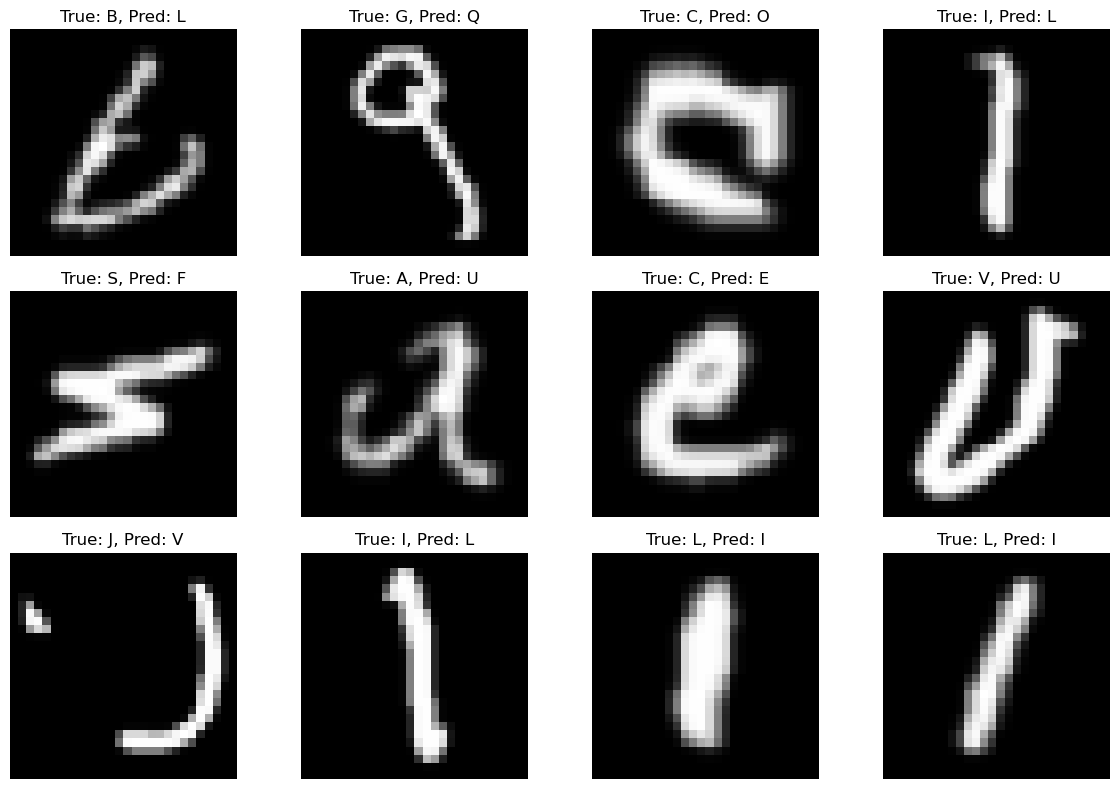

In [38]:
# Misclassified sample images
wrong_indices = np.where(final_test_pred != y_test)[0]

plt.figure(figsize=(12, 8))

sample_size = min(12, len(wrong_indices))
sample_indices = np.random.choice(wrong_indices, size=sample_size, replace=False)

for i, idx in enumerate(sample_indices):
    true_letter = class_names[y_test[idx]]
    predicted_letter = class_names[final_test_pred[idx]]
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title(f"True: {true_letter}, Pred: {predicted_letter}")
    plt.axis("off")

plt.tight_layout()
plt.show()


**Reflection:** The misclassified test samples show that many of the model's mistakes are visually understandable. Several incorrect predictions involve letters with very similar handwritten shapes, such as `I` and `L`, `G` and `Q`, `V` and `U`, and `C` and `E`. In these examples, the distinguishing strokes are small, unclear, or written in a style that overlaps with another class.

Some samples also appear ambiguous even to a human viewer. For example, the `I` and `L` samples look like simple vertical strokes, while the `G` sample has a rounded shape and tail that makes it similar to `Q`. This supports the confusion matrix findings that the model's remaining errors are mainly caused by shape similarity rather than random failure.

Overall, the misclassified samples confirm that the final model has learned the general letter patterns well, but still struggles when handwriting style removes or weakens the features that normally separate similar letters.


#### 7.10 Save Final Model Weights

The final model weights are saved in an `.h5` file so the trained model can be loaded again later without retraining. This also keeps the final submitted model consistent with the reported test result.


In [27]:
final_model.save_weights("CA1_PartA_final_model.weights.h5")

print("Final model weights saved as CA1_PartA_final_model.weights.h5")


Final model weights saved as CA1_PartA_final_model.weights.h5


#### 7.11 Reload Saved Weights Check

The saved weights are loaded into a newly rebuilt model with the same architecture. This checks that the `.h5` weights file was saved correctly and can be reused later without retraining.


In [39]:
# Rebuild the same final model architecture
loaded_final_model = Sequential()

loaded_final_model.add(Conv2D(32, (3, 3), padding="same", input_shape=(28, 28, 1)))
loaded_final_model.add(BatchNormalization())
loaded_final_model.add(LeakyReLU(alpha=0.1))
loaded_final_model.add(MaxPooling2D(pool_size=(2, 2)))

loaded_final_model.add(Conv2D(64, (3, 3), padding="same"))
loaded_final_model.add(BatchNormalization())
loaded_final_model.add(LeakyReLU(alpha=0.1))
loaded_final_model.add(MaxPooling2D(pool_size=(2, 2)))

loaded_final_model.add(Dropout(0.35))
loaded_final_model.add(Flatten())

loaded_final_model.add(Dense(384))
loaded_final_model.add(BatchNormalization())
loaded_final_model.add(LeakyReLU(alpha=0.1))
loaded_final_model.add(Dropout(0.40))

loaded_final_model.add(Dense(num_classes, activation="softmax"))

loaded_final_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Load saved weights
loaded_final_model.load_weights("CA1_PartA_final_model.weights.h5")

# Check loaded model performance
loaded_test_loss, loaded_test_accuracy = loaded_final_model.evaluate(X_test, y_test, verbose=0)

print("Loaded Model Test Loss: %.4f" % loaded_test_loss)
print("Loaded Model Test Accuracy: %.2f%%" % (loaded_test_accuracy * 100))


Loaded Model Test Loss: 0.1763
Loaded Model Test Accuracy: 94.16%


If the loaded model gives the same test result as the saved final model, it confirms that the weights file was saved and loaded correctly.


### Final Model Test Evaluation Summary

The final model was evaluated on the test set after all model selection and improvement steps were completed. The test set was not used during training or validation, so this result gives the fairest estimate of how well the selected model generalises to unseen handwritten letter images.

The final model achieved a test accuracy of **94.16%** and a test loss of **0.1763**. Out of **17,760** test images, the model correctly classified **16,723** images and misclassified **1,037** images. This gives a test error of **5.84%**.

The macro precision, macro recall, macro F1-score, and weighted F1-score are all around **0.94**. This shows that the model performs consistently across the 26 letter classes and is not only performing well because of a few easier classes. The macro and weighted F1-scores are also very close, which supports the earlier finding that the dataset is fairly balanced.

The class-level results show that most letters are classified well, with many classes achieving accuracy and F1-scores above **0.95**. However, the weakest classes are **I**, **L**, **G**, and **Q**. The main issue is between **I** and **L**, where both letters can appear as simple vertical strokes in handwriting. Another clear confusion is between **G** and **Q**, as both letters can have a rounded shape with only a small tail difference.

The normalized confusion matrix and top confused letter pairs confirm that the final model's errors are not random. Most mistakes are concentrated in visually similar letters such as **I/L**, **G/Q**, **U/V**, **D/O**, and **Y/V**. The misclassified sample images also support this, as several incorrect predictions are visually understandable even to a human viewer.

Overall, the final CNN model performs strongly on the unseen test data and generalises well. Its main limitation is distinguishing handwritten letters with very similar shapes. The final model weights are saved so the trained model can be reused later without retraining.


### 8. Gradio Demo Workflow

A simple Gradio interface is added after final model evaluation so the saved CNN model can be tested interactively. The interface allows a user to draw a letter, preprocesses the drawing into the same `28 x 28 x 1` format used during training, and returns the predicted alphabet class with confidence scores.


#### 8.1 Install and Import Gradio Libraries

Gradio is used to create the interactive web interface, while PIL is used to preprocess the drawn image before passing it into the CNN model.


In [18]:
!pip install gradio pillow

import gradio as gr
from PIL import Image, ImageOps


#### 8.2 Load Final Model Weights for Demo

The Gradio demo rebuilds the same final CNN architecture and loads the saved `.h5` weights. This avoids retraining the model and ensures the demo uses the submitted final model.


In [19]:
gradio_model = Sequential()

gradio_model.add(Conv2D(32, (3, 3), padding="same", input_shape=(28, 28, 1)))
gradio_model.add(BatchNormalization())
gradio_model.add(LeakyReLU(alpha=0.1))
gradio_model.add(MaxPooling2D(pool_size=(2, 2)))

gradio_model.add(Conv2D(64, (3, 3), padding="same"))
gradio_model.add(BatchNormalization())
gradio_model.add(LeakyReLU(alpha=0.1))
gradio_model.add(MaxPooling2D(pool_size=(2, 2)))

gradio_model.add(Dropout(0.35))
gradio_model.add(Flatten())

gradio_model.add(Dense(384))
gradio_model.add(BatchNormalization())
gradio_model.add(LeakyReLU(alpha=0.1))
gradio_model.add(Dropout(0.40))

gradio_model.add(Dense(num_classes, activation="softmax"))

gradio_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gradio_model.load_weights("CA1_PartA_final_model.weights.h5")

CLASS_NAMES = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

print("Final model weights loaded for Gradio demo.")


Final model weights loaded for Gradio demo.


#### 8.3 Preprocess Drawn Letter

The drawn image is converted to grayscale, inverted so the letter becomes white on a black background, cropped, resized, centred on a `28 x 28` canvas, normalised to `0-1`, and reshaped into CNN input format.


In [20]:
def preprocess_gradio_letter(image):
    if image is None:
        return None, None

    # Gradio ImageEditor may return a dictionary containing the final drawing.
    if isinstance(image, dict):
        image = image.get("composite", None)

    if image is None:
        return None, None

    if isinstance(image, np.ndarray):
        image = Image.fromarray(image)

    # Handle transparent canvases safely by placing them on a white background.
    if image.mode == "RGBA":
        white_background = Image.new("RGBA", image.size, (255, 255, 255, 255))
        image = Image.alpha_composite(white_background, image).convert("L")
    else:
        image = image.convert("L")

    image_array = np.array(image)

    # Detect whether the background is light or dark using the border pixels.
    border_pixels = np.concatenate([
        image_array[0, :],
        image_array[-1, :],
        image_array[:, 0],
        image_array[:, -1]
    ])
    background_is_light = border_pixels.mean() > 127

    # Training images use white letters on a black background.
    # If the drawing has black ink on a light background, invert it.
    if background_is_light:
        image = ImageOps.invert(image)

    # Threshold weak noise and keep the letter strokes.
    image = image.point(lambda pixel: 255 if pixel > 40 else 0)

    bbox = image.getbbox()
    if bbox is None:
        return None, None

    image = image.crop(bbox)

    # Resize longest side to 20 pixels, then centre on 28 x 28 canvas.
    image.thumbnail((20, 20), Image.Resampling.LANCZOS)

    canvas = Image.new("L", (28, 28), 0)
    left = (28 - image.width) // 2
    top = (28 - image.height) // 2
    canvas.paste(image, (left, top))

    model_input = np.array(canvas).astype("float32") / 255.0
    model_input = model_input.reshape(1, 28, 28, 1)

    return model_input, canvas


#### 8.4 Predict Letter from Drawing

The processed image is passed into the final CNN model. The model returns the predicted letter and the top confidence scores.


In [21]:
def predict_gradio_letter(image):
    processed_image, preview_image = preprocess_gradio_letter(image)

    if processed_image is None:
        return "Please draw a letter first.", None, {}

    predictions = gradio_model.predict(processed_image, verbose=0)[0]
    predicted_index = int(np.argmax(predictions))
    predicted_letter = CLASS_NAMES[predicted_index]
    confidence = float(predictions[predicted_index])

    prediction_text = f"Prediction: {predicted_letter} ({confidence:.2%})"

    confidence_scores = {
        CLASS_NAMES[i]: float(predictions[i])
        for i in range(len(CLASS_NAMES))
    }

    return prediction_text, preview_image, confidence_scores


#### 8.5 Launch Gradio Interface

The interface provides a drawing area, a prediction button, the processed `28 x 28` input preview, and the top confidence scores. This is mainly for demonstration and manual testing of the final saved model.


In [22]:
with gr.Blocks(title="EMNIST Handwritten Letter Classifier") as gradio_demo:
    gr.Markdown("# EMNIST Handwritten Letter Classifier")
    gr.Markdown("Draw one handwritten English letter, then click Predict.")

    with gr.Row():
        with gr.Column():
            sketchpad = gr.ImageEditor(
                label="Draw your letter here",
                type="pil",
                image_mode="RGBA",
                height=350,
                width=350,
                canvas_size=(350, 350),
                brush=gr.Brush(
                    colors=["#000000"],
                    default_color="#000000",
                    color_mode="fixed",
                    default_size=18
                ),
            )

            predict_button = gr.Button("Predict")

        with gr.Column():
            prediction_output = gr.Textbox(
                label="Model prediction",
                interactive=False
            )

            processed_output = gr.Image(
                label="Processed 28 x 28 model input",
                type="pil"
            )

            confidence_output = gr.Label(
                label="Top confidence scores",
                num_top_classes=5
            )

    predict_button.click(
        fn=predict_gradio_letter,
        inputs=sketchpad,
        outputs=[prediction_output, processed_output, confidence_output]
    )

gradio_demo.launch()


Running on local URL:  http://127.0.0.1:7862

To create a public link, set `share=True` in `launch()`.


**Reflection:** The Gradio workflow provides a practical demonstration of the final model. It also shows why preprocessing must match the training pipeline: the model expects centred, normalised `28 x 28 x 1` grayscale inputs, so the drawn image must be converted into that format before prediction.
